In [5]:
# Cell 1: Import libraries and load the survey data with THEMATIC organization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import textwrap
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle, Arrow, Rectangle, Wedge 
import matplotlib.lines as mlines
import matplotlib.patches as patches
import emoji
warnings.filterwarnings('ignore')

# Set style for better-looking visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the survey data from the 'SAMPLE DATA' sheet
df = pd.read_excel('Sample_Data_Edited.xlsx', sheet_name='SAMPLE DATA')

# Create shorter column names for easier handling (what happened to PVID?)
column_mapping = {
    'id. Response ID': 'response_id',
    'submitdate. Date submitted': 'submit_date',
    'lastpage. Last page': 'last_page',
    'startlanguage. Start language': 'language',
    'startdate. Date started': 'start_date',
    'datestamp. Date last action': 'last_action',
    'PVID. PVID Question.  Just make sure this is:  - Not using "always hide"  - Using the display class "hide question-pvid"  I have added a function in the theme that sets the pvid value to the quesitons with the given class. ': 'pvid',
    'site. Condition: {site}': 'condition',
    'origin. Source: {origin}': 'source',
    'CONQ01. Privacy policy: ': 'privacy_policy',
    'DEMQ01. Which best describes you? ': 'respondent_type',
    'DEMQ02. Which of the following best describes your ethnicity? ': 'ethnicity',
    'DEMQ03. Which of the following best describes your gender?': 'gender',
    'DEMQ04. Have you or the person in your care ever taken a medication that is specifically approved to treat {site}?': 'taken_medication',
    'DEMQ05. Please select your age range': 'age_range',
    'DEMQ06. How long ago did you or the person in your care receive a {site} diagnosis?': 'time_since_diagnosis',
    'SJOQ01. Which type of {site} do you or the person in your care have?': 'condition_type',
    'SJOQ02[SQ001]. How are you or the person in your care managing {site}? [How are you or the person in your care managing {site}?]': 'managing_how',
    'SJOQ02[SQ002]. How are you or the person in your care managing {site}? [Salagen (pilocarpine)]': 'managing_salagen',
    'SJOQ02[SQ003]. How are you or the person in your care managing {site}? [Evoxac (cevimeline)]': 'managing_evoxac',
    'SJOQ02[SQ004]. How are you or the person in your care managing {site}? [Not currently treating]': 'managing_not_treating',
    'SJOQ02[SQ005]. How are you or the person in your care managing {site}? [In a clinical trial for an experimental therapy.]': 'managing_clinical_trial',
    'SJOQ02[other]. How are you or the person in your care managing {site}? [Other]': 'managing_other',
    'CLOSEQ01. Are you considering exploring gene therapy as a treatment option, and how informed do you feel about available gene therapy options?': 'gene_therapy',
    'CLOSEQ02. How do you prefer to take your medication?': 'med_preference',
    'CLOSEQ02[other]. How do you prefer to take your medication? [Other]': 'med_preference_other',
    'CLOSEQ03. How satisfied are you with your current treatment plan?': 'satisfaction',
    'CLOSEQ04[SQ001]. Why are you satisfied? [The treatment is helping to manage or improve my condition.]': 'sat_managing',
    'CLOSEQ04[SQ002]. Why are you satisfied? [The treatment has few or manageable side effects.]': 'sat_side_effects',
    'CLOSEQ04[SQ003]. Why are you satisfied? [The treatment plan is simple and fits well into my daily routine.]': 'sat_routine',
    'CLOSEQ04[SQ004]. Why are you satisfied? [My healthcare providers clearly explain the treatment and its effects.]': 'sat_communication',
    'CLOSEQ04[SQ005]. Why are you satisfied? [The treatment is easy to access and affordable for me.]': 'sat_access',
    'CLOSEQ04[SQ006]. Why are you satisfied? [The treatment feels tailored to my specific needs and preferences.]': 'sat_tailored',
    'CLOSEQ04[other]. Why are you satisfied? [Other]': 'sat_other',
    'CLOSEQ05. How likely are you to change your current treatment plan?': 'change_likelihood',
    'CLOSEQ06. Are you interested in learning more about treating/managing {site}?': 'learning_interest'
}

df = df.rename(columns=column_mapping)

# Define THEMES for analysis (The instructions say "Present clear, well-chosen visuals (one per question or theme)" 
# Maybe it would make more sense to condense the columns by grouping them into "themes"?)

themes = {
    'Patient Demographics & Profile': {
        'columns': ['respondent_type', 'ethnicity', 'gender', 'age_range'],
        'description': 'Who are the survey respondents?'
    },
    'Disease Journey & Experience': {
        'columns': ['condition', 'condition_type', 'time_since_diagnosis', 'taken_medication'],
        'description': 'Understanding the patient journey from diagnosis to treatment'
    },
    'Current Treatment Management': {
        'columns': ['managing_salagen', 'managing_evoxac', 'managing_not_treating', 
                   'managing_clinical_trial', 'managing_other'],
        'description': 'How patients are currently managing their condition'
    },
    'Treatment Satisfaction & Drivers': {
        'columns': ['satisfaction', 'sat_managing', 'sat_side_effects', 'sat_routine',
                   'sat_communication', 'sat_access', 'sat_tailored', 'sat_other'],
        'description': 'Overall satisfaction and key factors driving it'
    },
    'Medication Preferences': {
        'columns': ['med_preference', 'med_preference_other'],
        'description': 'How patients prefer to receive their medication'
    },
    'Future Treatment Outlook': {
        'columns': ['change_likelihood', 'gene_therapy', 'learning_interest'],
        'description': 'Openness to change and interest in new treatments'
    },
    'Data Quality & Engagement': {
        'columns': ['privacy_policy', 'last_page', 'source'],
        'description': 'Survey completion and data quality metrics'
    }
}

# Display thematic overview
print("THEMATIC SURVEY ANALYSIS FRAMEWORK")
print("="*70)
print(f"Total responses: {len(df):,}")
print(f"Analysis organized into {len(themes)} key themes")
print("\nThemes and Coverage:")
print("-"*70)

for i, (theme_name, theme_data) in enumerate(themes.items(), 1):
    print(f"\n{i}. {theme_name}")
    print(f"   Purpose: {theme_data['description']}")
    print(f"   Questions included: {len(theme_data['columns'])}")
    
    # Calculate average response rate for this theme
    response_rates = []
    for col in theme_data['columns']:
        if col in df.columns:
            rate = (df[col].notna().sum() / len(df)) * 100
            response_rates.append(rate)
    if response_rates:
        avg_rate = np.mean(response_rates)
        print(f"   Average response rate: {avg_rate:.1f}%")

print("\n" + "="*70)

THEMATIC SURVEY ANALYSIS FRAMEWORK
Total responses: 639
Analysis organized into 7 key themes

Themes and Coverage:
----------------------------------------------------------------------

1. Patient Demographics & Profile
   Purpose: Who are the survey respondents?
   Questions included: 4
   Average response rate: 100.0%

2. Disease Journey & Experience
   Purpose: Understanding the patient journey from diagnosis to treatment
   Questions included: 4
   Average response rate: 100.0%

3. Current Treatment Management
   Purpose: How patients are currently managing their condition
   Questions included: 5
   Average response rate: 89.3%

4. Treatment Satisfaction & Drivers
   Purpose: Overall satisfaction and key factors driving it
   Questions included: 8
   Average response rate: 32.7%

5. Medication Preferences
   Purpose: How patients prefer to receive their medication
   Questions included: 2
   Average response rate: 53.8%

6. Future Treatment Outlook
   Purpose: Openness to change 

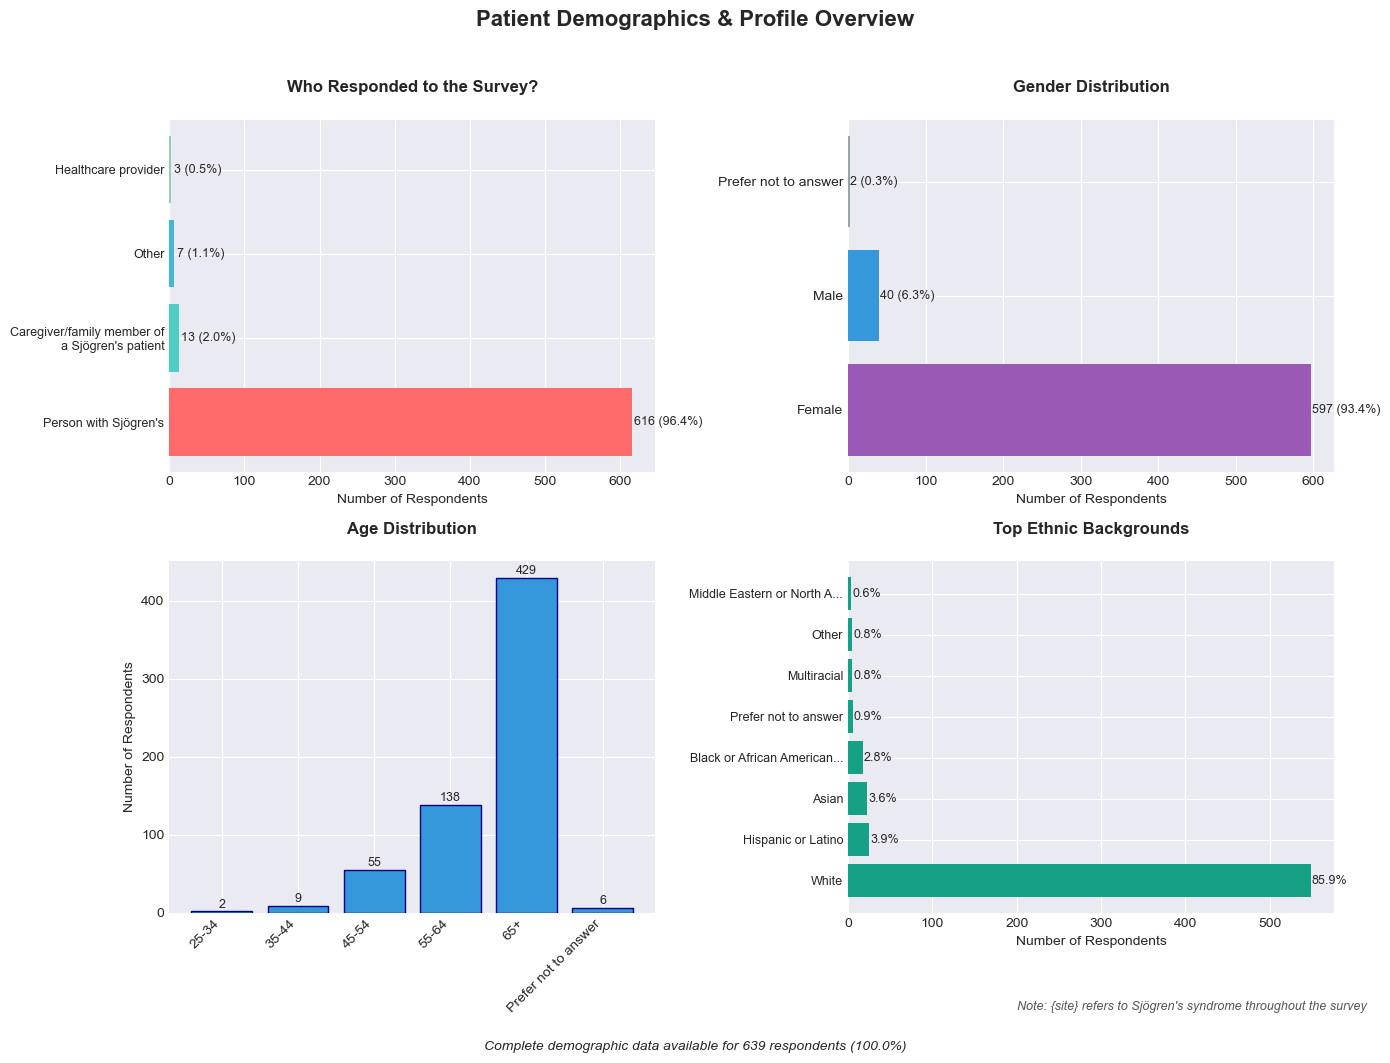


KEY DEMOGRAPHIC INSIGHTS:
--------------------------------------------------
• Primary respondent type: Person with {site} (96.4%)
• Gender distribution: Female dominant (93.4%)
• Most common age group: 65+ (429 respondents, 67.1%)
• Top ethnicity: White (85.9%)

• Survey focuses on Sjögren's syndrome patients and their caregivers


In [6]:
# Cell 2: Theme 1 - Patient Demographics & Profile
# Creating a comprehensive demographic overview visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Patient Demographics & Profile Overview', fontsize=16, fontweight='bold', y=1.02)

# 1. Respondent Type (Top Left)
ax1 = axes[0, 0]
respondent_data = df['respondent_type'].value_counts()
# Use horizontal bars for better label readability
bars = ax1.barh(range(len(respondent_data)), respondent_data.values, 
                color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFA07A'][:len(respondent_data)])
ax1.set_yticks(range(len(respondent_data)))
# Clean up the labels - replace {site} with Sjögren's
ylabels = [str(label).replace('{site}', "Sjögren's") for label in respondent_data.index]
# Wrap long labels
wrapped_labels = []
for label in ylabels:
    if len(label) > 40:
        words = label.split()
        mid = len(words) // 2
        wrapped_labels.append(' '.join(words[:mid]) + '\n' + ' '.join(words[mid:]))
    else:
        wrapped_labels.append(label)
ax1.set_yticklabels(wrapped_labels, fontsize=9)
ax1.set_xlabel('Number of Respondents', fontsize=10)
ax1.set_title('Who Responded to the Survey?', fontsize=12, fontweight='bold', pad=20)
# Add value labels with percentages
for bar, value in zip(bars, respondent_data.values):
    percentage = value/len(df)*100
    ax1.text(value + 3, bar.get_y() + bar.get_height()/2, 
             f'{value} ({percentage:.1f}%)', va='center', fontsize=9)

# 2. Gender Distribution (Top Right)
ax2 = axes[0, 1]
gender_data = df['gender'].value_counts()

# Define colors for specific gender labels
color_map = {
    'Male': '#3498DB',          # blue
    'Female': '#9B59B6',        # purple
    'Prefer not to say': '#D2B48C',  # light beige / taupe
}

# Assign colors based on the index of gender_data
bar_colors = [color_map.get(label, '#95A5A6') for label in gender_data.index]

# Create the horizontal bar chart
bars = ax2.barh(range(len(gender_data)), gender_data.values, color=bar_colors)

ax2.set_yticks(range(len(gender_data)))
ax2.set_yticklabels([
    str(label)[:30] + '...' if len(str(label)) > 30 else str(label)
    for label in gender_data.index
])
ax2.set_xlabel('Number of Respondents', fontsize=10)
ax2.set_title('Gender Distribution', fontsize=12, fontweight='bold', pad=20)

# Add value labels on bars
for bar, value in zip(bars, gender_data.values):
    ax2.text(
        value + 1,
        bar.get_y() + bar.get_height()/2,
        f'{value} ({value/len(df)*100:.1f}%)',
        va='center',
        fontsize=9
    )

# 3. Age Range Distribution (Bottom Left)
ax3 = axes[1, 0]
age_data = df['age_range'].value_counts().sort_index()
# Define a logical order for age ranges
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+', '75 or older']
ordered_age = []
ordered_counts = []
for age in age_order:
    if age in age_data.index:
        ordered_age.append(age)
        ordered_counts.append(age_data[age])
# Add any remaining age categories not in our predefined order
for age in age_data.index:
    if age not in age_order:
        ordered_age.append(age)
        ordered_counts.append(age_data[age])

bars = ax3.bar(range(len(ordered_age)), ordered_counts, 
               color='#3498DB', edgecolor='navy', linewidth=1)
ax3.set_xticks(range(len(ordered_age)))
ax3.set_xticklabels(ordered_age, rotation=45, ha='right')
ax3.set_ylabel('Number of Respondents', fontsize=10)
ax3.set_title('Age Distribution', fontsize=12, fontweight='bold', pad=20)
# Add value labels on top of bars
for bar, value in zip(bars, ordered_counts):
    ax3.text(bar.get_x() + bar.get_width()/2, value + 1, 
             str(value), ha='center', va='bottom', fontsize=9)

# 4. Ethnicity Distribution (Bottom Right)
ax4 = axes[1, 1]
ethnicity_data = df['ethnicity'].value_counts().head(8)  # Top 8 for readability
y_pos = range(len(ethnicity_data))
bars = ax4.barh(y_pos, ethnicity_data.values, color='#16A085')
ax4.set_yticks(y_pos)
# Truncate long ethnicity labels for readability
ax4.set_yticklabels([str(label)[:25] + '...' if len(str(label)) > 25 else str(label) 
                      for label in ethnicity_data.index], fontsize=9)
ax4.set_xlabel('Number of Respondents', fontsize=10)
ax4.set_title('Top Ethnic Backgrounds', fontsize=12, fontweight='bold', pad=20)
# Add percentage labels
for i, (bar, value) in enumerate(zip(bars, ethnicity_data.values)):
    percentage = value/df['ethnicity'].notna().sum()*100
    ax4.text(value + 1, bar.get_y() + bar.get_height()/2, 
             f'{percentage:.1f}%', va='center', fontsize=9)

# Add note about {site} = Sjögren's syndrome
fig.text(0.98, 0.02, 'Note: {site} refers to Sjögren\'s syndrome throughout the survey', 
         ha='right', fontsize=9, style='italic', color='#555555')

# Add response rate annotation
total_demographics_response = df[['respondent_type', 'gender', 'age_range', 'ethnicity']].notna().all(axis=1).sum()
fig.text(0.5, -0.02, f'Complete demographic data available for {total_demographics_response} respondents ({total_demographics_response/len(df)*100:.1f}%)', 
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# --- SAFE KEY STATISTICS (fixed) ---
# Most frequent respondent type / gender (safely)
primary_respondent = respondent_data.idxmax() if not respondent_data.empty else 'N/A'
primary_respondent_pct = (respondent_data.max()/len(df)*100) if not respondent_data.empty else 0

primary_gender = gender_data.idxmax() if not gender_data.empty else 'N/A'
primary_gender_pct = (gender_data.max()/len(df)*100) if not gender_data.empty else 0

# Most common age group (use counts, not sorted index)
most_common_age = age_data.idxmax() if not age_data.empty else 'N/A'
most_common_age_count = age_data.max() if not age_data.empty else 0
most_common_age_pct = (most_common_age_count / len(df) * 100) if len(df) > 0 else 0

# Top ethnicity safely (use notna denominator)
top_ethnicity = ethnicity_data.idxmax() if not ethnicity_data.empty else 'N/A'
top_ethnicity_pct = (ethnicity_data.max() / df['ethnicity'].notna().sum() * 100) if df['ethnicity'].notna().sum() > 0 else 0

print("\nKEY DEMOGRAPHIC INSIGHTS:")
print("-" * 50)
print(f"• Primary respondent type: {primary_respondent} ({primary_respondent_pct:.1f}%)")
print(f"• Gender distribution: {primary_gender} dominant ({primary_gender_pct:.1f}%)")
print(f"• Most common age group: {most_common_age} ({most_common_age_count} respondents, {most_common_age_pct:.1f}%)")
print(f"• Top ethnicity: {top_ethnicity} ({top_ethnicity_pct:.1f}%)")
print("\n• Survey focuses on Sjögren's syndrome patients and their caregivers")

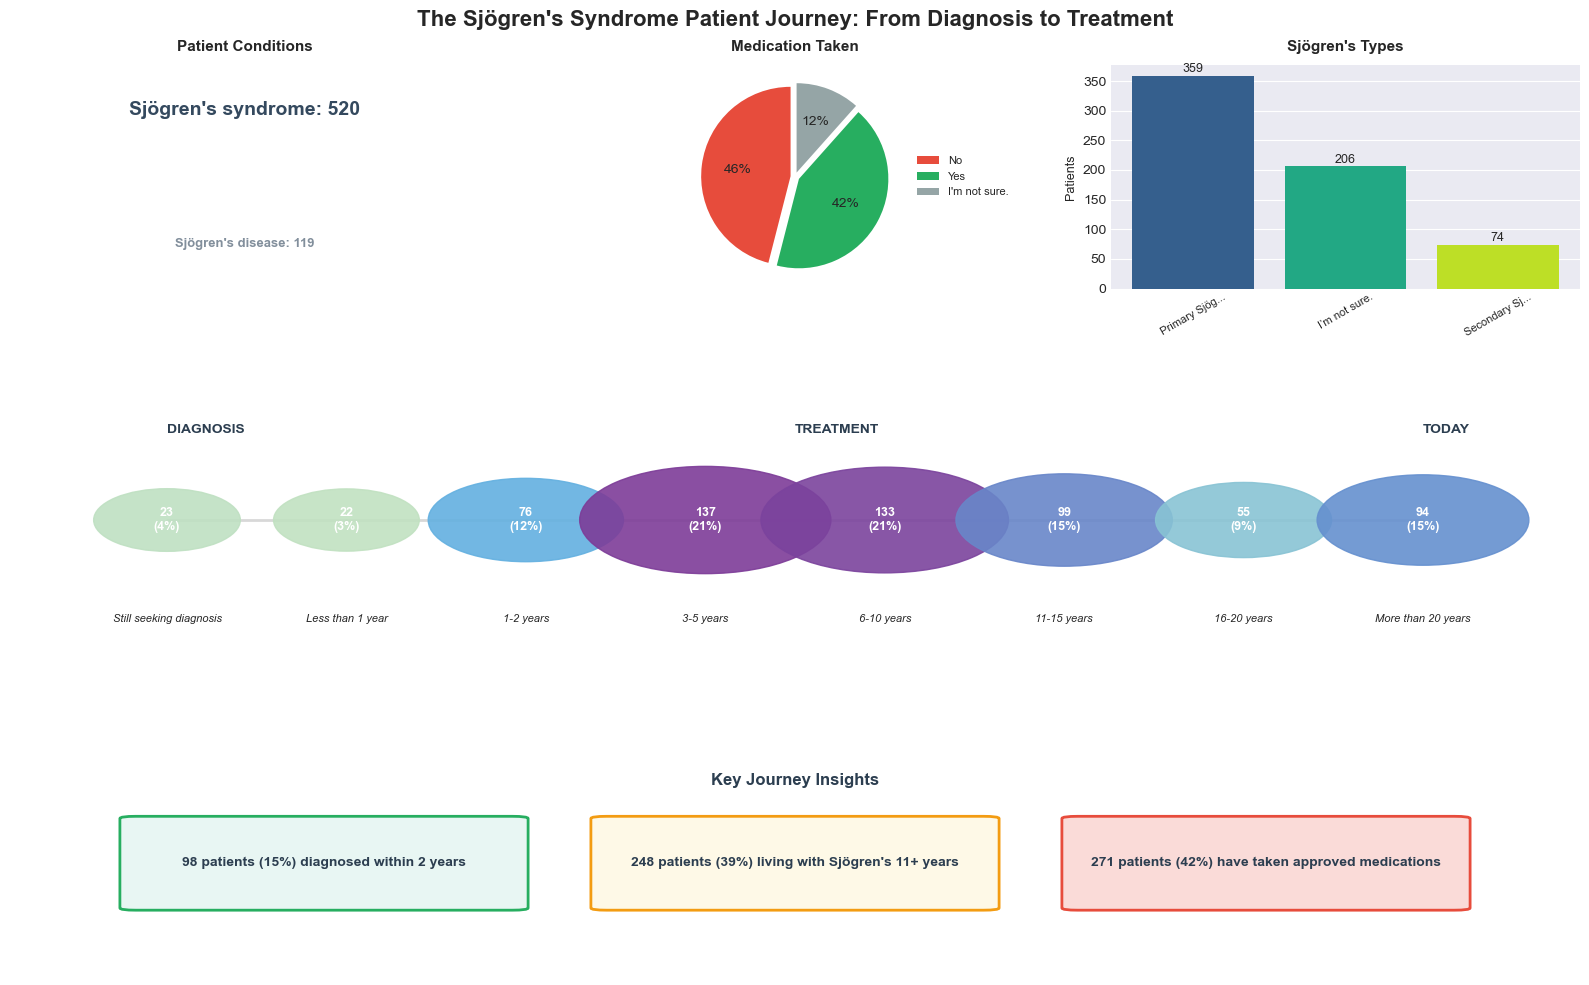


PATIENT JOURNEY ANALYSIS:
------------------------------------------------------------
• Most patients are long-term: 38.8% diagnosed 11+ years ago
• Primary condition type: Primary Sjögren’s disease
• Treatment adoption: 271 of 639 patients have tried approved medications
• Journey spans from new diagnoses to 20+ year veterans


In [7]:
# Cell 3: Theme 2 - Disease Journey & Experience (Improved Timeline)
# --- CLEAN & NORMALIZE TIME SINCE DIAGNOSIS ---

def categorize_diagnosis_time(val):
    if pd.isna(val):
        return 'Unknown'
    v = str(val).strip().lower()

    if 'still seeking' in v:
        return 'Still seeking diagnosis'
    elif 'less than' in v:
        return 'Less than 1 year'
    elif '1-2' in v or '1 – 2' in v:
        return '1-2 years'
    elif '3-5' in v or '3 – 5' in v:
        return '3-5 years'
    elif '6-10' in v or '6 – 10' in v:
        return '6-10 years'
    elif '11-15' in v or '11 – 15' in v:
        return '11-15 years'
    elif '16-20' in v or '16 – 20' in v:
        return '16-20 years'
    elif 'more than 20' in v or '20+' in v:
        return 'More than 20 years'
    elif '20' in v:
        return 'More than 20 years'
    else:
        return 'Other / Unclear'

# Apply cleaning directly to the already mapped column
df['time_since_diagnosis'] = df['time_since_diagnosis'].apply(categorize_diagnosis_time)

# --- SETUP FIGURE ---
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1.5, 1], width_ratios=[1, 1, 1])

ax_main = fig.add_subplot(gs[1, :])
ax_condition = fig.add_subplot(gs[0, 0])
ax_medication = fig.add_subplot(gs[0, 1])
ax_condition_type = fig.add_subplot(gs[0, 2])
ax_bottom = fig.add_subplot(gs[2, :])

fig.suptitle("The Sjögren's Syndrome Patient Journey: From Diagnosis to Treatment",
             fontsize=16, fontweight='bold', y=0.98)

# --- MAIN JOURNEY TIMELINE (updated color logic) ---
ax_main.set_xlim(0, 10)
ax_main.set_ylim(0, 5)
ax_main.axis('off')

time_order = [
    'Still seeking diagnosis',
    'Less than 1 year',
    '1-2 years',
    '3-5 years',
    '6-10 years',
    '11-15 years',
    '16-20 years',
    'More than 20 years'
]
time_data = df['time_since_diagnosis'].value_counts()
time_present = [t for t in time_order if t in time_data.index]
journey_x = np.linspace(1, 9, len(time_present))
journey_y = [2.5] * len(time_present)

# Color intensity based on number of respondents
import matplotlib.cm as cm
import matplotlib.colors as mcolors
norm = mcolors.Normalize(vmin=time_data.min(), vmax=time_data.max())
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_teal_purple",
    ["#C1E1C1", "#5DADE2", "#7D3C98"]  # light mint → blue → deep purple
)
norm = mcolors.Normalize(vmin=time_data.min(), vmax=time_data.max())
time_colors_map = {cat: cmap(norm(time_data[cat])) for cat in time_data.index}

# Draw timeline
for i, (x, milestone) in enumerate(zip(journey_x, time_present)):
    count = time_data[milestone]
    pct = count / len(df) * 100
    size = (count / time_data.max()) * 2000 + 500
    circle = Circle((x, 2.5), radius=0.3 + (size/5000),
                    color=time_colors_map.get(milestone, '#D3D3D3'),
                    alpha=0.9, zorder=2)
    ax_main.add_patch(circle)
    ax_main.text(x, 2.5, f'{count}\n({pct:.0f}%)',
                 ha='center', va='center', fontweight='bold',
                 fontsize=9, color='white', zorder=3)
    ax_main.text(x, 1.1, milestone, ha='center', va='top', fontsize=8, style='italic')

# Connect the milestones
for i in range(len(journey_x)-1):
    ax_main.plot([journey_x[i], journey_x[i+1]], [2.5, 2.5],
                 'gray', linewidth=2, alpha=0.3, zorder=1)

# Add journey stage labels
ax_main.text(1, 3.8, 'DIAGNOSIS', fontweight='bold', fontsize=10, color='#2C3E50')
ax_main.text(5, 3.8, 'TREATMENT', fontweight='bold', fontsize=10, color='#2C3E50')
ax_main.text(9, 3.8, 'TODAY', fontweight='bold', fontsize=10, color='#2C3E50')

# --- CONDITION SOURCES (Top Left) ---
ax_condition.axis('off')
condition_data = df['condition'].value_counts()
y_positions = np.linspace(0.8, 0.2, len(condition_data))
for i, (condition, count) in enumerate(condition_data.items()):
    condition_text = str(condition).replace('{site}', "Sjögren's")
    if len(condition_text) > 30:
        condition_text = condition_text[:27] + '...'
    size = 8 + (count / condition_data.max()) * 6
    alpha = 0.5 + (count / condition_data.max()) * 0.5
    ax_condition.text(0.5, y_positions[i], f'{condition_text}: {count}',
                      ha='center', va='center', fontsize=size,
                      alpha=alpha, color='#34495E', fontweight='bold')
ax_condition.set_title('Patient Conditions', fontsize=11, fontweight='bold', pad=10)

# --- MEDICATION HISTORY (Top Middle) ---
taken_med_data = df['taken_medication'].value_counts()
colors = ['#E74C3C', '#27AE60', '#95A5A6']
wedges, texts, autotexts = ax_medication.pie(
    taken_med_data.values,
    autopct='%1.0f%%',
    startangle=90,
    colors=colors[:len(taken_med_data)],
    explode=[0.05]*len(taken_med_data)
)
med_labels = [str(label).replace('{site}', "Sjögren's")[:40] + '...'
              if len(str(label).replace('{site}', "Sjögren's")) > 40
              else str(label).replace('{site}', "Sjögren's")
              for label in taken_med_data.index]
ax_medication.legend(med_labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax_medication.set_title('Medication Taken', fontsize=11, fontweight='bold', pad=10)

# --- CONDITION TYPES (Top Right) ---
condition_type_data = df['condition_type'].value_counts().head(5)
bars = ax_condition_type.bar(range(len(condition_type_data)),
                             condition_type_data.values,
                             color=plt.cm.viridis(np.linspace(0.3, 0.9, len(condition_type_data))))
ax_condition_type.set_xticks([])
ax_condition_type.set_ylabel('Patients', fontsize=9)
ax_condition_type.set_title("Sjögren's Types", fontsize=11, fontweight='bold', pad=10)

for i, (bar, value, label) in enumerate(zip(bars, condition_type_data.values, condition_type_data.index)):
    ax_condition_type.text(bar.get_x() + bar.get_width()/2, value + 1,
                           str(value), ha='center', va='bottom', fontsize=9)
    label_text = str(label).replace('{site}', "Sjögren's")
    if len(label_text) > 15:
        label_text = label_text[:12] + '...'
    ax_condition_type.text(bar.get_x() + bar.get_width()/2, -5,
                           label_text, ha='center', va='top', rotation=30, fontsize=8)

# --- JOURNEY INSIGHTS (Bottom) ---
ax_bottom.axis('off')

# Recalculate insights using cleaned categories
early_diagnosis = df[df['time_since_diagnosis'].isin(['Less than 1 year', '1-2 years'])].shape[0]
long_term = df[df['time_since_diagnosis'].isin(['11-15 years', '16-20 years', 'More than 20 years'])].shape[0]
on_treatment = df[df['taken_medication'].str.contains('Yes', case=False, na=False)].shape[0]

insights = [
    f"{early_diagnosis} patients ({early_diagnosis/len(df)*100:.0f}%) diagnosed within 2 years",
    f"{long_term} patients ({long_term/len(df)*100:.0f}%) living with Sjögren's 11+ years",
    f"{on_treatment} patients ({on_treatment/len(df)*100:.0f}%) have taken approved medications"
]

box_x_positions = [0.2, 0.5, 0.8]
for i, (x_pos, insight) in enumerate(zip(box_x_positions, insights)):
    bbox = FancyBboxPatch((x_pos - 0.12, 0.3), 0.24, 0.4,
                          boxstyle="round,pad=0.01",
                          facecolor=['#E8F6F3', '#FEF9E7', '#FADBD8'][i],
                          edgecolor=['#27AE60', '#F39C12', '#E74C3C'][i],
                          linewidth=2, transform=ax_bottom.transAxes)
    ax_bottom.add_patch(bbox)
    ax_bottom.text(x_pos, 0.5, insight, ha='center', va='center',
                   transform=ax_bottom.transAxes, fontsize=10,
                   fontweight='bold', color='#2C3E50')

ax_bottom.text(0.5, 0.85, 'Key Journey Insights', ha='center',
               transform=ax_bottom.transAxes, fontsize=12,
               fontweight='bold', color='#2C3E50')

plt.tight_layout()
plt.show()

# --- PRINT ADDITIONAL INSIGHTS ---
print("\nPATIENT JOURNEY ANALYSIS:")
print("-" * 60)
print(f"• Most patients are long-term: {long_term/len(df)*100:.1f}% diagnosed 11+ years ago")
print(f"• Primary condition type: {condition_type_data.index[0] if len(condition_type_data) > 0 else 'N/A'}")
print(f"• Treatment adoption: {on_treatment} of {len(df)} patients have tried approved medications")
print(f"• Journey spans from new diagnoses to 20+ year veterans")


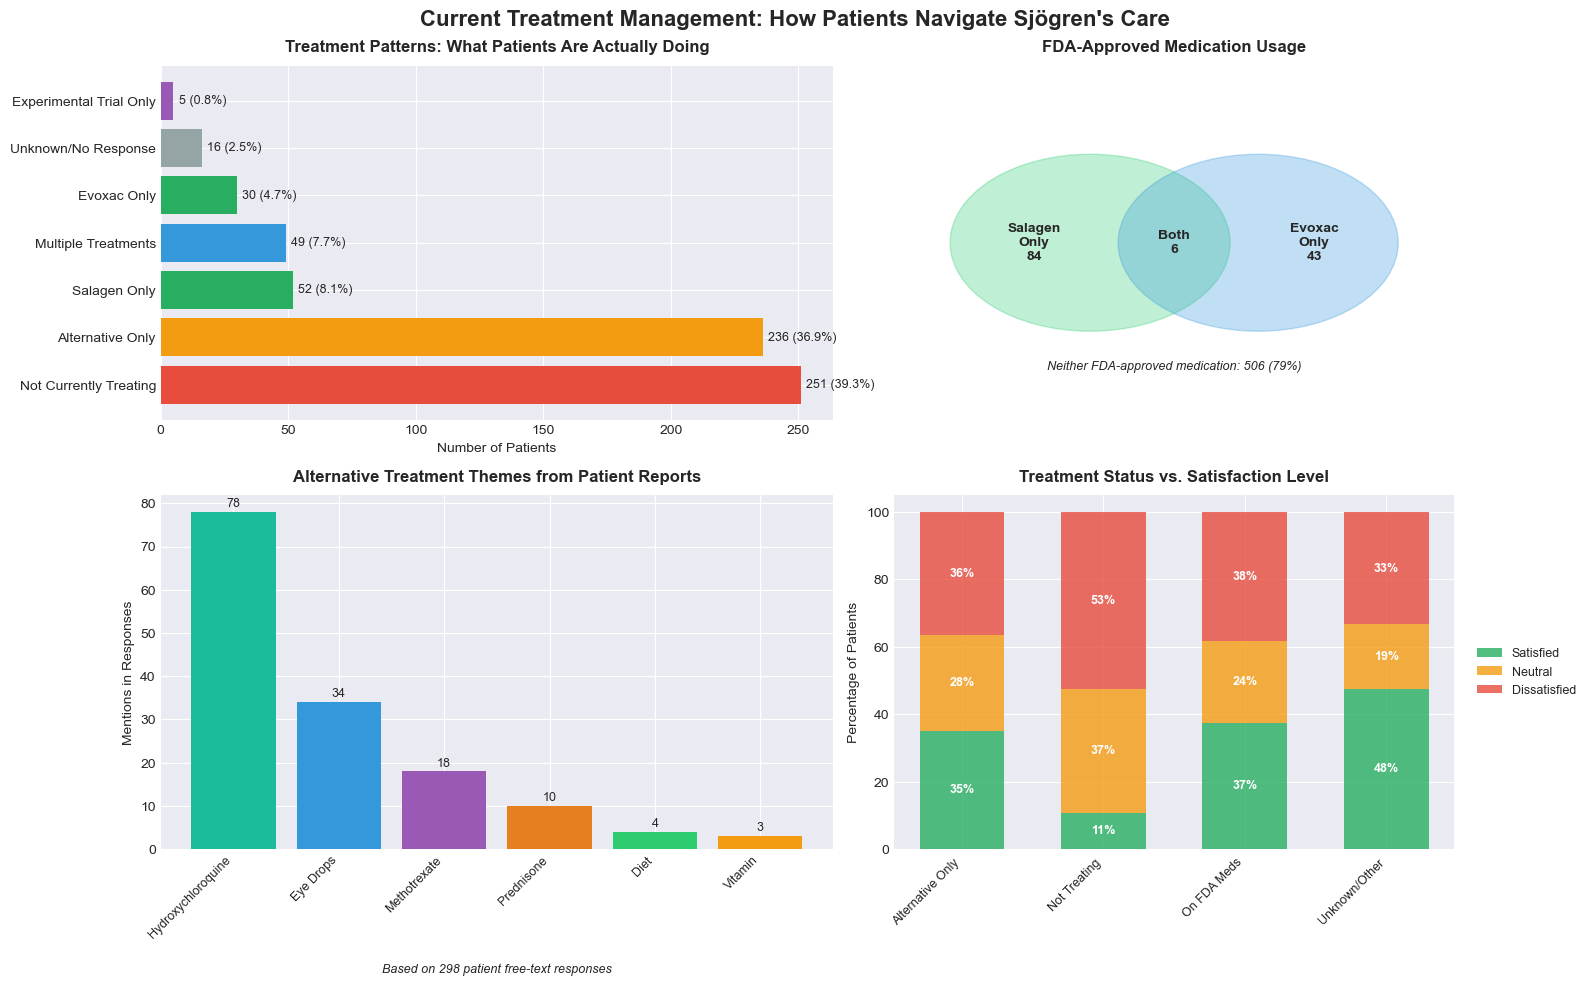


TREATMENT MANAGEMENT INSIGHTS:
------------------------------------------------------------
• Most common approach: Not Currently Treating (36.440677966101696 patients, 5.7%)
• FDA medication usage: 133 patients total
  - Salagen only: 84
  - Evoxac only: 43
  - Both medications: 6
• Not currently treating: 251 patients
• Alternative treatments mentioned: 298 patients provided details


In [8]:
# Cell 4: Theme 3 - Current Treatment Management (Streamlined Treatment Landscape)
# Creating a comprehensive treatment overview with clear, non-overlapping visualizations

fig = plt.figure(figsize=(16, 10))

# Create custom layout - simpler 2x2 grid
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1.2, 1])

# Treatment combinations (top left - main focus)
ax_combos = fig.add_subplot(gs[0, 0])

# Specific medication usage (top right)
ax_meds = fig.add_subplot(gs[0, 1])

# Alternative treatments word cloud (bottom left)
ax_text = fig.add_subplot(gs[1, 0])

# Treatment satisfaction cross-analysis (bottom right)
ax_cross = fig.add_subplot(gs[1, 1])

fig.suptitle('Current Treatment Management: How Patients Navigate Sjögren\'s Care', 
             fontsize=16, fontweight='bold', y=0.98)

# --- TREATMENT COMBINATIONS (Top Left - Main Focus) ---
ax_combos.set_title('Treatment Patterns: What Patients Are Actually Doing', 
                    fontsize=12, fontweight='bold', pad=10)

# Calculate MUTUALLY EXCLUSIVE treatment categories
treatment_categories = []
for idx, row in df.iterrows():
    if row['managing_not_treating'] == 'Yes':
        treatment_categories.append('Not Currently Treating')
    else:
        treatments = []
        if row['managing_salagen'] == 'Yes':
            treatments.append('Salagen')
        if row['managing_evoxac'] == 'Yes':
            treatments.append('Evoxac')
        if row['managing_clinical_trial'] == 'Yes':
            treatments.append('Experimental Trial')
        if pd.notna(row['managing_other']):
            treatments.append('Alternative')
        
        if treatments:
            if len(treatments) == 1:
                treatment_categories.append(treatments[0] + ' Only')
            else:
                treatment_categories.append('Multiple Treatments')
        else:
            treatment_categories.append('Unknown/No Response')

from collections import Counter
category_counts = Counter(treatment_categories)

# Sort by frequency
sorted_categories = dict(sorted(category_counts.items(), key=lambda x: x[1], reverse=True))

# Create horizontal bar chart with gradient colors
y_pos = range(len(sorted_categories))
values = list(sorted_categories.values())
labels = list(sorted_categories.keys())

# Use color coding: red for not treating, green for active treatment, gray for unknown
colors = []
for label in labels:
    if 'Not Currently' in label:
        colors.append('#E74C3C')
    elif 'Unknown' in label:
        colors.append('#95A5A6')
    elif 'Multiple' in label:
        colors.append('#3498DB')
    elif 'Experimental' in label:
        colors.append('#9B59B6')
    elif 'Alternative' in label:
        colors.append('#F39C12')
    else:
        colors.append('#27AE60')

bars = ax_combos.barh(y_pos, values, color=colors)
ax_combos.set_yticks(y_pos)
ax_combos.set_yticklabels(labels, fontsize=10)
ax_combos.set_xlabel('Number of Patients', fontsize=10)

# Add value labels with percentages
for bar, val in zip(bars, values):
    pct = val/len(df)*100
    ax_combos.text(val + 2, bar.get_y() + bar.get_height()/2,
                   f'{val} ({pct:.1f}%)', va='center', fontsize=9)

# --- SPECIFIC MEDICATIONS BREAKDOWN (Top Right) ---
ax_meds.set_title('FDA-Approved Medication Usage', fontsize=12, fontweight='bold', pad=10)

# Calculate medication overlap
only_salagen = df[(df['managing_salagen'] == 'Yes') & (df['managing_evoxac'] != 'Yes')].shape[0]
only_evoxac = df[(df['managing_evoxac'] == 'Yes') & (df['managing_salagen'] != 'Yes')].shape[0]
both_meds = df[(df['managing_salagen'] == 'Yes') & (df['managing_evoxac'] == 'Yes')].shape[0]
neither = len(df) - only_salagen - only_evoxac - both_meds

# Create Venn diagram style visualization using circles
ax_meds.set_xlim(0, 10)
ax_meds.set_ylim(0, 10)
ax_meds.axis('off')

# Draw circles
circle1 = patches.Circle((3.5, 5), 2.5, alpha=0.3, color='#2ECC71', label='Salagen')
circle2 = patches.Circle((6.5, 5), 2.5, alpha=0.3, color='#3498DB', label='Evoxac')
ax_meds.add_patch(circle1)
ax_meds.add_patch(circle2)

# Add text labels with counts
ax_meds.text(2.5, 5, f'Salagen\nOnly\n{only_salagen}', ha='center', va='center', 
            fontweight='bold', fontsize=10)
ax_meds.text(7.5, 5, f'Evoxac\nOnly\n{only_evoxac}', ha='center', va='center', 
            fontweight='bold', fontsize=10)
ax_meds.text(5, 5, f'Both\n{both_meds}', ha='center', va='center', 
            fontweight='bold', fontsize=10)
ax_meds.text(5, 1.5, f'Neither FDA-approved medication: {neither} ({neither/len(df)*100:.0f}%)', 
            ha='center', va='center', fontsize=9, style='italic')

# --- ALTERNATIVE TREATMENTS TEXT ANALYSIS (Bottom Left) ---
ax_text.set_title('Alternative Treatment Themes from Patient Reports', 
                  fontsize=12, fontweight='bold', pad=10)

# Analyze the "managing_other" text responses
other_treatments = df['managing_other'].dropna()

if len(other_treatments) > 0:
    # Count common words/themes
    all_text = ' '.join(other_treatments.astype(str).str.lower())
    
    # Common treatment words to look for
    treatment_keywords = {
        'vitamin': all_text.count('vitamin'),
        'eye drops': all_text.count('eye drop') + all_text.count('artificial tear'),
        'hydroxychloroquine': all_text.count('hydroxychloroquine') + all_text.count('plaquenil'),
        'methotrexate': all_text.count('methotrexate'),
        'prednisone': all_text.count('prednisone') + all_text.count('steroid'),
        'diet': all_text.count('diet'),
        'supplement': all_text.count('supplement'),
        'natural': all_text.count('natural') + all_text.count('herbal'),
        'immunosuppressant': all_text.count('immunosuppressant') + all_text.count('immune')
    }
    
    # Filter and sort
    active_treatments = {k: v for k, v in treatment_keywords.items() if v > 0}
    sorted_treatments = dict(sorted(active_treatments.items(), key=lambda x: x[1], reverse=True)[:6])
    
    if sorted_treatments:
        # Create vertical bar chart with distinct colors (not a gradient)
        x_pos = range(len(sorted_treatments))
        treatment_names = list(sorted_treatments.keys())
        treatment_counts = list(sorted_treatments.values())
        
        # Use distinct colors instead of gradient
        bar_colors = ['#1ABC9C', '#3498DB', '#9B59B6', '#E67E22', '#2ECC71', '#F39C12']
        
        bars = ax_text.bar(x_pos, treatment_counts, color=bar_colors[:len(sorted_treatments)])
        
        ax_text.set_xticks(x_pos)
        ax_text.set_xticklabels([name.title() for name in treatment_names], 
                                rotation=45, ha='right', fontsize=9)
        ax_text.set_ylabel('Mentions in Responses', fontsize=10)
        
        # Add value labels
        for bar, count in zip(bars, treatment_counts):
            ax_text.text(bar.get_x() + bar.get_width()/2, count + 0.5,
                        str(count), ha='center', va='bottom', fontsize=9)
        
        # Add note
        ax_text.text(0.5, -0.35, f'Based on {len(other_treatments)} patient free-text responses',
                    ha='center', transform=ax_text.transAxes, fontsize=9, style='italic')
else:
    ax_text.text(0.5, 0.5, 'No alternative treatment descriptions provided', 
                ha='center', va='center', transform=ax_text.transAxes,
                fontsize=12, color='gray')
    ax_text.axis('off')

# --- TREATMENT VS SATISFACTION CROSS-ANALYSIS (Bottom Right) ---
ax_cross.set_title('Treatment Status vs. Satisfaction Level', fontsize=12, fontweight='bold', pad=10)

# Create cross-tabulation
treatment_status = []
for idx, row in df.iterrows():
    if row['managing_not_treating'] == 'Yes':
        treatment_status.append('Not Treating')
    elif row['managing_salagen'] == 'Yes' or row['managing_evoxac'] == 'Yes':
        treatment_status.append('On FDA Meds')
    elif pd.notna(row['managing_other']):
        treatment_status.append('Alternative Only')
    else:
        treatment_status.append('Unknown/Other')

# Add to dataframe temporarily
df['treatment_status_temp'] = treatment_status

# Create satisfaction groupings
satisfaction_map = {
    'Very satisfied': 'Satisfied',
    'Somewhat satisfied': 'Satisfied',
    'Neither satisfied nor dissatisfied': 'Neutral',
    'Somewhat dissatisfied': 'Dissatisfied',
    'Very dissatisfied': 'Dissatisfied'
}
df['satisfaction_grouped'] = df['satisfaction'].map(satisfaction_map)

# Create crosstab
crosstab = pd.crosstab(df['treatment_status_temp'], df['satisfaction_grouped'], normalize='index') * 100

# Create stacked bar chart
if not crosstab.empty:
    crosstab_ordered = crosstab.reindex(columns=['Satisfied', 'Neutral', 'Dissatisfied'], fill_value=0)
    
    x = np.arange(len(crosstab_ordered.index))
    width = 0.6
    
    colors_stack = ['#27AE60', '#F39C12', '#E74C3C']
    bottom = np.zeros(len(x))
    
    for i, col in enumerate(crosstab_ordered.columns):
        values = crosstab_ordered[col].values
        bars = ax_cross.bar(x, values, width, bottom=bottom, 
                           label=col, color=colors_stack[i], alpha=0.8)
        
        # Add percentage labels for significant segments
        for j, (bar, val) in enumerate(zip(bars, values)):
            if val > 10:  # Only show if >10%
                ax_cross.text(bar.get_x() + bar.get_width()/2, 
                            bottom[j] + val/2,
                            f'{val:.0f}%', ha='center', va='center',
                            color='white', fontweight='bold', fontsize=9)
        bottom += values
    
    ax_cross.set_ylabel('Percentage of Patients', fontsize=10)
    ax_cross.set_xticks(x)
    # Adjust label rotation to prevent overlap with title
    ax_cross.set_xticklabels(crosstab_ordered.index, rotation=45, ha='right', fontsize=9)
    ax_cross.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),  # shift legend to the right
    fontsize=9,
    frameon=False)
    ax_cross.set_ylim(0, 105)
    
    # Add some padding to prevent label overlap
    ax_cross.tick_params(axis='x', pad=5)

# Clean up temporary column
df = df.drop(['treatment_status_temp', 'satisfaction_grouped'], axis=1)

plt.tight_layout()
plt.show()

# Print key insights
print("\nTREATMENT MANAGEMENT INSIGHTS:")
print("-" * 60)
print(f"• Most common approach: {labels[0]} ({values[0]} patients, {values[0]/len(df)*100:.1f}%)")
print(f"• FDA medication usage: {only_salagen + only_evoxac + both_meds} patients total")
print(f"  - Salagen only: {only_salagen}")
print(f"  - Evoxac only: {only_evoxac}")
print(f"  - Both medications: {both_meds}")
print(f"• Not currently treating: {category_counts.get('Not Currently Treating', 0)} patients")
print(f"• Alternative treatments mentioned: {len(other_treatments)} patients provided details")

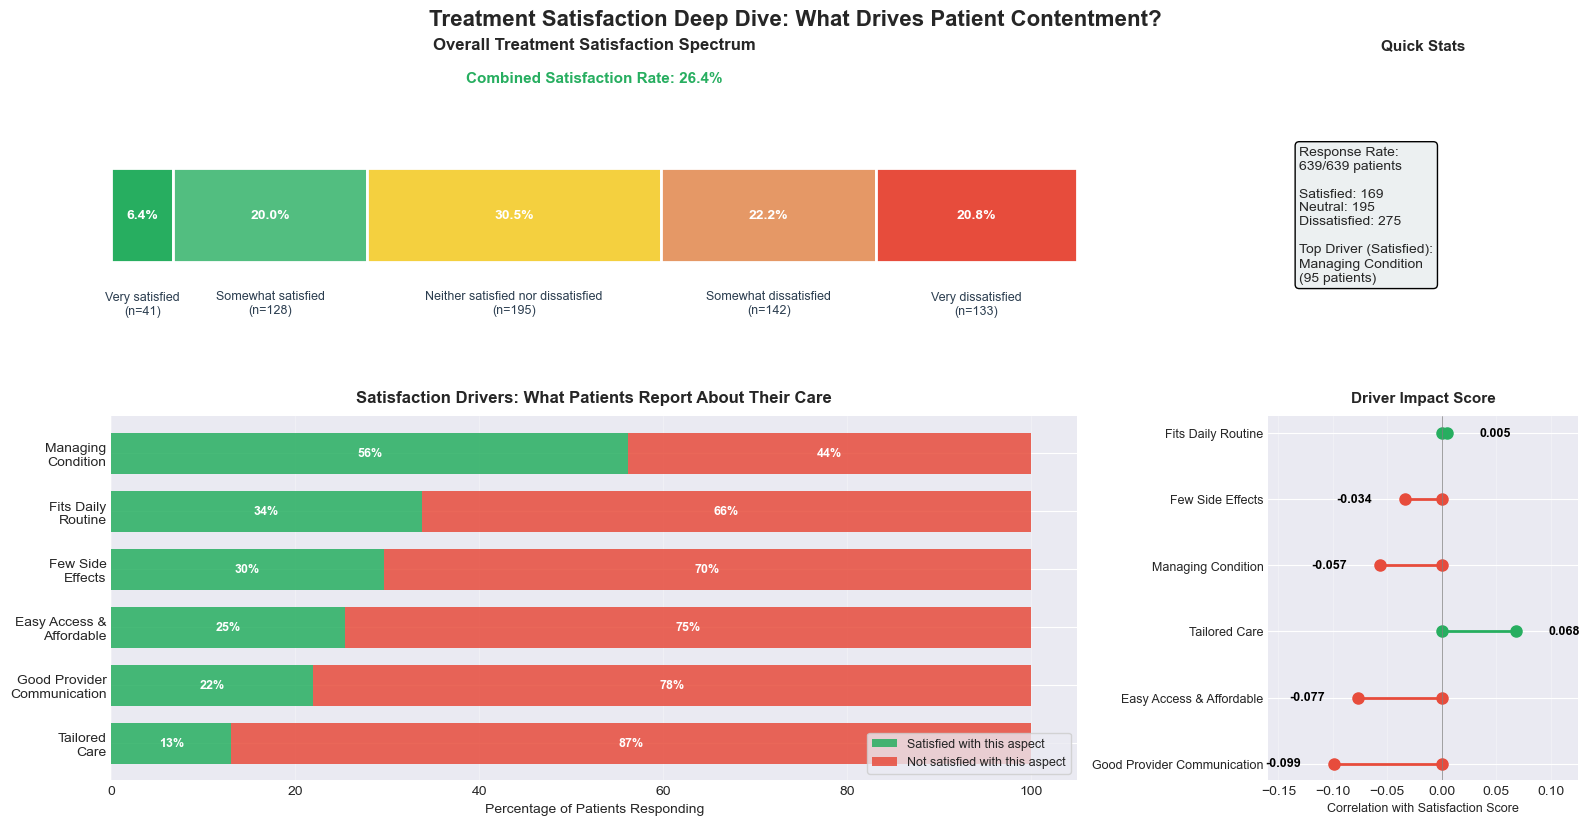


SATISFACTION DRIVER INSIGHTS:
------------------------------------------------------------
• Overall satisfaction rate: 26.4% satisfied or very satisfied
• Most impactful driver: Good Provider Communication (correlation: -0.099)
• Least impactful driver: Fits Daily Routine (correlation: 0.005)
• Pattern: Satisfaction increases with number of positive drivers reported


In [9]:
# Cell 5: Theme 4 - Treatment Satisfaction & Drivers (Multi-dimensional Analysis)
# Creating an innovative satisfaction dashboard with driver analysis

fig = plt.figure(figsize=(16, 11))

# Create custom grid layout
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1.2, 0.8], width_ratios=[1.5, 1, 1])

# Overall satisfaction distribution (top left, spanning 2 columns)
ax_overall = fig.add_subplot(gs[0, :2])

# Satisfaction drivers heatmap (middle left, spanning 2 columns)
ax_drivers = fig.add_subplot(gs[1, :2])

# Key insights box (top right)
ax_insights = fig.add_subplot(gs[0, 2])

# Driver importance ranking (middle right)
ax_ranking = fig.add_subplot(gs[1, 2])

fig.suptitle('Treatment Satisfaction Deep Dive: What Drives Patient Contentment?', 
             fontsize=16, fontweight='bold', y=0.98)

# --- OVERALL SATISFACTION DISTRIBUTION (Top) ---
ax_overall.set_title('Overall Treatment Satisfaction Spectrum', fontsize=12, fontweight='bold', pad=10)

satisfaction_order = ['Very satisfied', 'Somewhat satisfied', 'Neither satisfied nor dissatisfied', 
                     'Somewhat dissatisfied', 'Very dissatisfied']
satisfaction_data = df['satisfaction'].value_counts().reindex(satisfaction_order, fill_value=0)

# Create horizontal stacked bar for visual impact
colors_gradient = ['#27AE60', '#52BE80', '#F4D03F', '#E59866', '#E74C3C']
x_cumulative = 0
total = len(df[df['satisfaction'].notna()])

for i, (level, count) in enumerate(satisfaction_data.items()):
    width = count / total
    rect = ax_overall.barh(0, width, left=x_cumulative, height=0.5, 
                           color=colors_gradient[i], edgecolor='white', linewidth=2)
    
    # Add percentage labels
    if count > 0:
        pct = count/total*100
        label_x = x_cumulative + width/2
        ax_overall.text(label_x, 0, f'{pct:.1f}%', ha='center', va='center',
                       fontweight='bold', fontsize=10, color='white')
        ax_overall.text(label_x, -0.4, f'{level}\n(n={count})', ha='center', va='top',
                       fontsize=9, color='#2C3E50')
    x_cumulative += width

ax_overall.set_xlim(0, 1)
ax_overall.set_ylim(-0.8, 0.8)
ax_overall.axis('off')

# Add satisfaction score
satisfied_count = satisfaction_data['Very satisfied'] + satisfaction_data['Somewhat satisfied']
satisfied_pct = satisfied_count / total * 100
ax_overall.text(0.5, 0.7, f'Combined Satisfaction Rate: {satisfied_pct:.1f}%', 
               ha='center', fontsize=11, fontweight='bold', color='#27AE60')

# --- SATISFACTION DRIVER RESPONSES (Middle Left) ---
ax_drivers.set_title('Satisfaction Drivers: What Patients Report About Their Care', 
                     fontsize=12, fontweight='bold', pad=10)

driver_cols = ['sat_managing', 'sat_side_effects', 'sat_routine', 
               'sat_communication', 'sat_access', 'sat_tailored']
driver_labels = ['Managing\nCondition', 'Few Side\nEffects', 'Fits Daily\nRoutine', 
                 'Good Provider\nCommunication', 'Easy Access &\nAffordable', 'Tailored\nCare']

# Calculate proportions of Yes/No for each driver
driver_summary = []
for col, label in zip(driver_cols, driver_labels):
    yes_count = (df[col] == 'Yes').sum()
    no_count = (df[col] == 'No').sum()
    total = yes_count + no_count
    if total > 0:
        yes_pct = yes_count / total * 100
        no_pct = no_count / total * 100
    else:
        yes_pct = no_pct = 0
    driver_summary.append((label, yes_pct, no_pct, total))

# Convert to DataFrame for plotting
driver_df = pd.DataFrame(driver_summary, columns=['Driver', 'Yes_%', 'No_%', 'Total'])

# Sort by Yes% for better visual
driver_df = driver_df.sort_values('Yes_%', ascending=True)

# Create horizontal stacked bar chart for better label readability
y_pos = np.arange(len(driver_df))
bar_height = 0.7

# Plot Yes (green) and No (red) portions
bars_yes = ax_drivers.barh(y_pos, driver_df['Yes_%'].values, height=bar_height, 
                           color='#27AE60', label='Satisfied with this aspect', alpha=0.85)
bars_no = ax_drivers.barh(y_pos, driver_df['No_%'].values, height=bar_height, 
                          left=driver_df['Yes_%'].values, color='#E74C3C', 
                          label='Not satisfied with this aspect', alpha=0.85)

# Labels and formatting
ax_drivers.set_yticks(y_pos)
ax_drivers.set_yticklabels(driver_df['Driver'].values, fontsize=10)
ax_drivers.set_xlabel('Percentage of Patients Responding', fontsize=10)
ax_drivers.set_xlim(0, 105)
ax_drivers.legend(loc='lower right', fontsize=9, frameon=True, fancybox=True)
ax_drivers.grid(axis='x', alpha=0.3)

# Add % labels on bars (only if segment is large enough)
for i, (yes, no) in enumerate(zip(driver_df['Yes_%'].values, driver_df['No_%'].values)):
    if yes > 10:
        ax_drivers.text(yes/2, i, f'{yes:.0f}%', ha='center', va='center', 
                       color='white', fontweight='bold', fontsize=9)
    if no > 10:
        ax_drivers.text(yes + no/2, i, f'{no:.0f}%', ha='center', va='center', 
                       color='white', fontweight='bold', fontsize=9)

# --- KEY INSIGHTS BOX (Top Right) ---
ax_insights.axis('off')
ax_insights.set_title('Quick Stats', fontsize=11, fontweight='bold', pad=10)

# Calculate key metrics
total_satisfied = df[df['satisfaction'].isin(['Very satisfied', 'Somewhat satisfied'])].shape[0]
total_dissatisfied = df[df['satisfaction'].isin(['Somewhat dissatisfied', 'Very dissatisfied'])].shape[0]

# Most common driver for satisfied patients
satisfied_df = df[df['satisfaction'].isin(['Very satisfied', 'Somewhat satisfied'])]
driver_counts = {}
for driver, label in zip(driver_cols, driver_labels):
    driver_counts[label] = (satisfied_df[driver] == 'Yes').sum()
top_driver = max(driver_counts, key=driver_counts.get) if driver_counts else 'N/A'

insights_text = f"""Response Rate:
{df['satisfaction'].notna().sum()}/{len(df)} patients

Satisfied: {total_satisfied}
Neutral: {df[df['satisfaction']=='Neither satisfied nor dissatisfied'].shape[0]}
Dissatisfied: {total_dissatisfied}

Top Driver (Satisfied):
{top_driver.replace(chr(10), ' ')}
({driver_counts.get(top_driver, 0)} patients)"""

ax_insights.text(0.1, 0.5, insights_text, transform=ax_insights.transAxes,
                fontsize=10, verticalalignment='center', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='#ECF0F1'))

# --- DRIVER IMPORTANCE RANKING (Middle Right) ---
ax_ranking.set_title('Driver Impact Score', fontsize=11, fontweight='bold', pad=10)

# Create numeric satisfaction scale for correlation analysis
satisfaction_numeric = {
    'Very satisfied': 5, 'Somewhat satisfied': 4, 
    'Neither satisfied nor dissatisfied': 3,
    'Somewhat dissatisfied': 2, 'Very dissatisfied': 1
}
df['satisfaction_score'] = df['satisfaction'].map(satisfaction_numeric)

# Calculate impact score (correlation with satisfaction)
impact_scores = []
for driver, label in zip(driver_cols, driver_labels):
    # Calculate correlation between driver and satisfaction score
    driver_binary = (df[driver] == 'Yes').astype(float)
    # Only calculate if we have valid data
    valid_mask = df[driver].notna() & df['satisfaction_score'].notna()
    if valid_mask.sum() > 10:  # Need at least 10 valid responses
        correlation = driver_binary[valid_mask].corr(df['satisfaction_score'][valid_mask])
        if not np.isnan(correlation):
            impact_scores.append((label.replace('\n', ' '), correlation))

# Sort by absolute impact (strongest relationships first)
impact_scores.sort(key=lambda x: abs(x[1]), reverse=True)

if impact_scores:
    # Create lollipop chart
    y_pos = range(len(impact_scores))
    impacts = [score[1] for score in impact_scores]
    labels_impact = [score[0] for score in impact_scores]
    
    # Color code by positive/negative correlation
    colors_lollipop = ['#27AE60' if impact > 0 else '#E74C3C' for impact in impacts]
    
    # Plot lollipops
    for y, impact, color in zip(y_pos, impacts, colors_lollipop):
        ax_ranking.plot([0, impact], [y, y], 'o-', color=color, linewidth=2, markersize=8)
    
    ax_ranking.set_yticks(y_pos)
    ax_ranking.set_yticklabels(labels_impact, fontsize=9)
    ax_ranking.set_xlabel('Correlation with Satisfaction Score', fontsize=9)
    ax_ranking.set_xlim(min(impacts) * 1.1 - 0.05, max(impacts) * 1.1 + 0.05)
    ax_ranking.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
    ax_ranking.grid(True, axis='x', alpha=0.3)
    
        # Add value labels (fixed spacing for visibility)
    for y, impact in zip(y_pos, impacts):
        if impact >= 0:
            ha = 'left'
            x_offset = 0.03  # push right
        else:
            ha = 'right'
            x_offset = -0.03  # push left
        
        ax_ranking.text(
            impact + x_offset, y, f'{impact:.3f}',
            va='center', ha=ha, fontsize=9, fontweight='bold',
            color='black'
        )
# Clean up temporary columns
df = df.drop(['satisfaction_score', 'positive_driver_count'], axis=1, errors='ignore')

plt.tight_layout()
plt.show()

# Print insights
print("\nSATISFACTION DRIVER INSIGHTS:")
print("-" * 60)
print(f"• Overall satisfaction rate: {satisfied_pct:.1f}% satisfied or very satisfied")
if impact_scores:
    print(f"• Most impactful driver: {labels_impact[0]} (correlation: {impacts[0]:.3f})")
    print(f"• Least impactful driver: {labels_impact[-1]} (correlation: {impacts[-1]:.3f})")
print(f"• Pattern: Satisfaction increases with number of positive drivers reported")

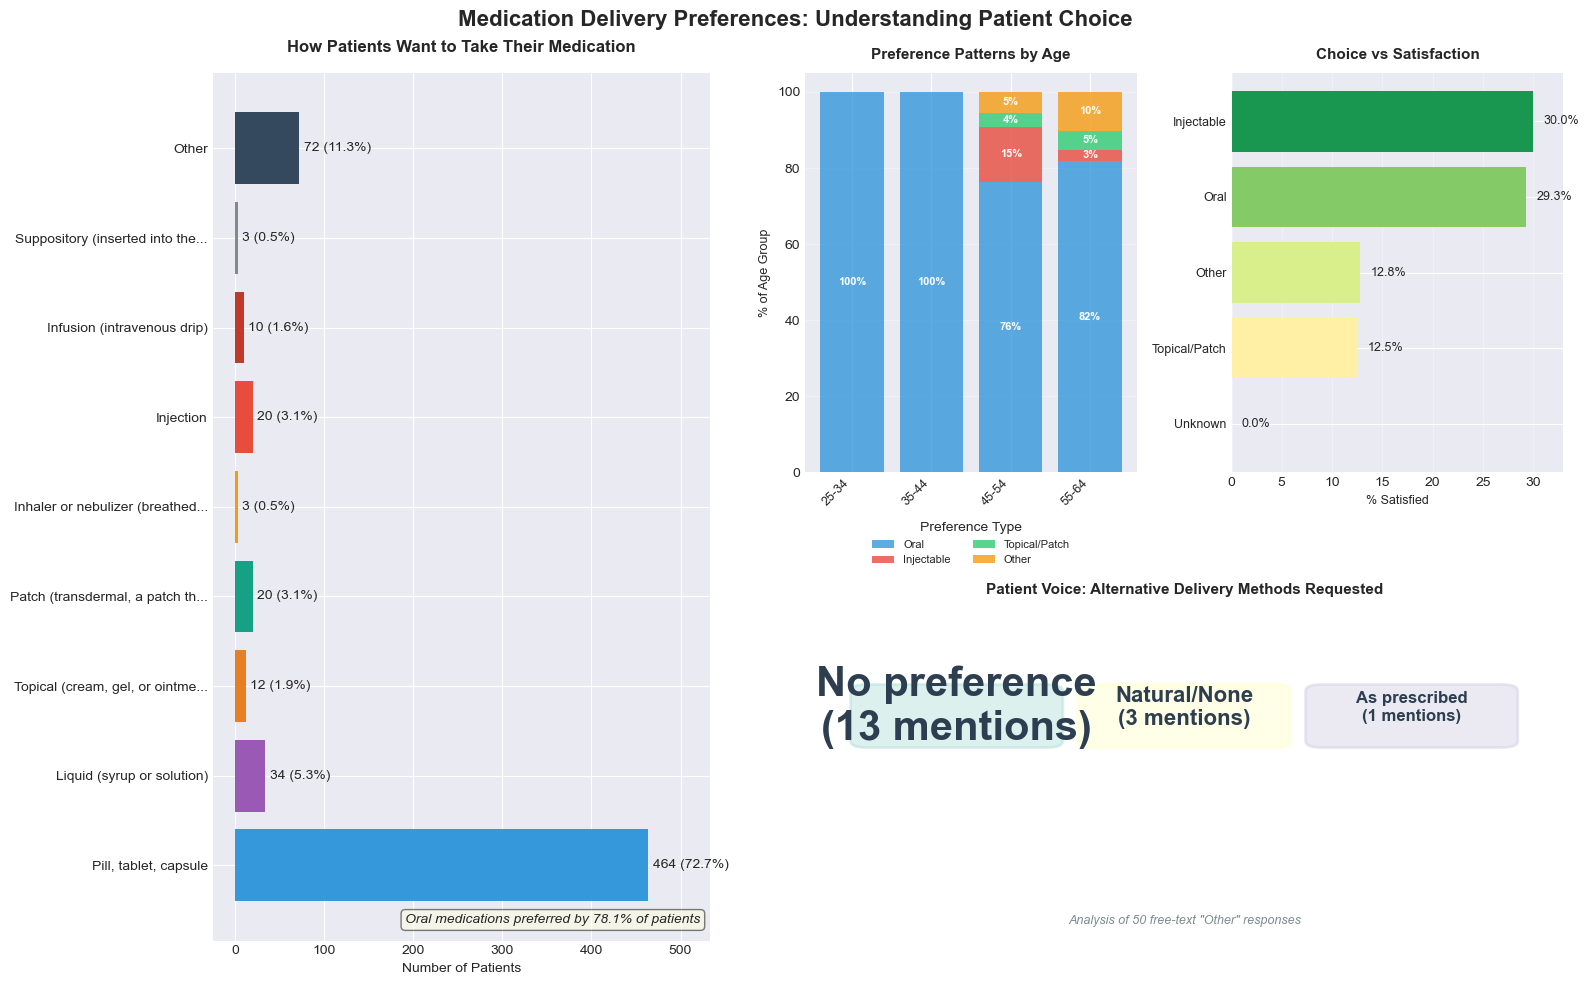


MEDICATION PREFERENCE INSIGHTS:
------------------------------------------------------------
• Top preference: Pill, tablet, capsule (464 patients)
• Oral medications preferred by 78.1% of patients
• Injectable methods (injection/infusion): 4.7%
• 50 patients specified alternative preferences
• Most common 'Other' theme: No preference (13 mentions)


In [10]:
# Cell 6: Theme 5 - Medication Preferences (Patient Choice Architecture)
# Creating a comprehensive view of how patients prefer to receive their treatments


fig = plt.figure(figsize=(16, 10))

# Create custom layout
gs = fig.add_gridspec(2, 3, height_ratios=[1.2, 1], width_ratios=[1.5, 1, 1])

# Main preference distribution (left, spanning both rows)
ax_main = fig.add_subplot(gs[:, 0])

# Preference by demographics (top middle)
ax_demo = fig.add_subplot(gs[0, 1])

# Preference by satisfaction (top right)
ax_sat = fig.add_subplot(gs[0, 2])

# Text analysis of "other" preferences (bottom, spanning middle and right)
ax_text = fig.add_subplot(gs[1, 1:])

fig.suptitle('Medication Delivery Preferences: Understanding Patient Choice', 
             fontsize=16, fontweight='bold', y=0.98)

# --- MAIN PREFERENCE DISTRIBUTION (Left) ---
ax_main.set_title('How Patients Want to Take Their Medication', fontsize=12, fontweight='bold', pad=15)

# Get medication preference data
med_pref_data = df['med_preference'].value_counts()

# Define custom order (from least to most invasive)
pref_order = [
    'Pill, tablet, capsule',
    'Liquid (syrup or solution)',
    'Topical (cream, gel, or ointment applied to the skin)',
    'Patch (transdermal, a patch that sticks to the skin)',
    'Inhaler or nebulizer (breathed into the lungs)',
    'Injection',
    'Infusion (intravenous drip)',
    'Suppository (inserted into the rectum, vagina, or urethra)',
    'Other'
]

# Reorder data
med_pref_ordered = med_pref_data.reindex([p for p in pref_order if p in med_pref_data.index], fill_value=0)

# Create horizontal bar chart with icons/colors
colors_pref = ['#3498DB', '#9B59B6', '#E67E22', '#16A085', '#F39C12', 
               '#E74C3C', '#C0392B', '#7F8C8D', '#34495E']

y_pos = range(len(med_pref_ordered))
bars = ax_main.barh(y_pos, med_pref_ordered.values, color=colors_pref[:len(med_pref_ordered)])

# Customize bars
for i, (bar, val) in enumerate(zip(bars, med_pref_ordered.values)):
    # Add percentage and count
    pct = val/df['med_preference'].notna().sum()*100
    ax_main.text(val + 5, bar.get_y() + bar.get_height()/2,
                f'{val} ({pct:.1f}%)', va='center', fontsize=10)
    
ax_main.set_yticks(y_pos)
ax_main.set_yticklabels([label[:30] + '...' if len(label) > 30 else label 
                         for label in med_pref_ordered.index], fontsize=10)
ax_main.set_xlabel('Number of Patients', fontsize=10)
ax_main.set_xlim(-25, max(med_pref_ordered.values) * 1.15)

# Add insight annotation
oral_total = med_pref_ordered.get('Pill, tablet, capsule', 0) + med_pref_ordered.get('Liquid (syrup or solution)', 0)
oral_pct = oral_total / df['med_preference'].notna().sum() * 100
ax_main.text(0.98, 0.02, f'Oral medications preferred by {oral_pct:.1f}% of patients',
            transform=ax_main.transAxes, ha='right', fontsize=10, style='italic',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightyellow', alpha=0.5))

# --- PREFERENCE BY AGE GROUP (Top Middle) ---
ax_demo.set_title('Preference Patterns by Age', fontsize=11, fontweight='bold', pad=10)

# Simplify preferences into categories
def categorize_preference(pref):
    if pd.isna(pref):
        return 'Unknown'
    elif 'Pill' in pref or 'Liquid' in pref:
        return 'Oral'
    elif 'Injection' in pref or 'Infusion' in pref:
        return 'Injectable'
    elif 'Topical' in pref or 'Patch' in pref:
        return 'Topical/Patch'
    else:
        return 'Other'

df['pref_category'] = df['med_preference'].apply(categorize_preference)

# Create age groups (simplified)
age_groups = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75 or older']
pref_categories = ['Oral', 'Injectable', 'Topical/Patch', 'Other']

# Create crosstab
age_pref_crosstab = pd.crosstab(df['age_range'], df['pref_category'], normalize='index') * 100

# Filter to main categories and age groups that exist
existing_age_groups = [age for age in age_groups if age in age_pref_crosstab.index]
if existing_age_groups and not age_pref_crosstab.empty:
    age_pref_filtered = age_pref_crosstab.loc[existing_age_groups, 
                                              [cat for cat in pref_categories if cat in age_pref_crosstab.columns]]
    
# Create stacked bar chart
x = range(len(existing_age_groups))
bottom = np.zeros(len(existing_age_groups))
colors_stack = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']

for i, category in enumerate([cat for cat in pref_categories if cat in age_pref_filtered.columns]):
    values = age_pref_filtered[category].values
    bars = ax_demo.bar(x, values, bottom=bottom, width=0.8,
                       label=category, color=colors_stack[i], alpha=0.8)

    # --- ADD PERCENTAGE LABELS ON EACH SEGMENT ---
    for j, (val, btm) in enumerate(zip(values, bottom)):
        if val > 2:  # Only label segments > 2% to avoid clutter
            ax_demo.text(
                j,                                  # x position (center of the bar)
                btm + val / 2,                      # vertical center of the segment
                f'{val:.0f}%',                      # label text
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold'
            )

    bottom += values
    
    ax_demo.set_xticks(x)
    ax_demo.set_xticklabels([age[:5] for age in existing_age_groups], rotation=45, ha='right', fontsize=9)
    ax_demo.set_ylabel('% of Age Group', fontsize=9)
    ax_demo.set_ylim(0, 105)
    ax_demo.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.10),  # move below plot
        fontsize=8,
        frameon=False,
        ncol=2,  # spread horizontally
        title='Preference Type'
    )
    ax_demo.grid(axis='y', alpha=0.3)

# --- PREFERENCE BY SATISFACTION (Top Right) ---
ax_sat.set_title('Choice vs Satisfaction', fontsize=11, fontweight='bold', pad=10)

# Calculate average satisfaction by preference category
sat_by_pref = df.groupby('pref_category')['satisfaction'].apply(
    lambda x: (x.isin(['Very satisfied', 'Somewhat satisfied'])).mean() * 100
).sort_values(ascending=True)

# Create horizontal bar chart
if not sat_by_pref.empty:
    y_pos = range(len(sat_by_pref))
    bars = ax_sat.barh(y_pos, sat_by_pref.values, 
                      color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(sat_by_pref))))
    
    ax_sat.set_yticks(y_pos)
    ax_sat.set_yticklabels(sat_by_pref.index, fontsize=9)
    ax_sat.set_xlabel('% Satisfied', fontsize=9)
    ax_sat.set_xlim(0, max(sat_by_pref.values) * 1.1)
    
    # Add value labels
    for bar, val in zip(bars, sat_by_pref.values):
        ax_sat.text(val + 1, bar.get_y() + bar.get_height()/2,
                   f'{val:.1f}%', va='center', fontsize=9)
    
    ax_sat.grid(axis='x', alpha=0.3)

# --- TEXT ANALYSIS OF "OTHER" PREFERENCES (Bottom) ---
ax_text.set_title('Patient Voice: Alternative Delivery Methods Requested', 
                  fontsize=11, fontweight='bold', pad=10)

# Analyze "other" text responses
other_prefs = df['med_preference_other'].dropna()

if len(other_prefs) > 0:
    # Common themes to look for
    themes = {
        'No preference': ['no preference', 'doesn\'t matter', 'don\'t care', 'any', 'whatever'],
        'Avoid needles': ['no needle', 'no injection', 'hate needle', 'afraid'],
        'Natural/None': ['natural', 'no medication', 'diet', 'exercise', 'none'],
        'Easiest method': ['easy', 'easiest', 'convenient', 'simple'],
        'As prescribed': ['prescribed', 'doctor', 'recommended', 'whatever works'],
        'Sublingual': ['sublingual', 'under tongue', 'dissolve']
    }
    
    theme_counts = {}
    all_text = ' '.join(other_prefs.astype(str).str.lower())
    
    for theme, keywords in themes.items():
        count = sum(all_text.count(keyword) for keyword in keywords)
        if count > 0:
            theme_counts[theme] = count
    
    if theme_counts:
        # Sort and get top themes
        sorted_themes = sorted(theme_counts.items(), key=lambda x: x[1], reverse=True)[:6]
        
        # Create word cloud style visualization with different sizes
        ax_text.axis('off')
        
        # Position themes in a grid pattern
        positions = [(0.2, 0.7), (0.5, 0.7), (0.8, 0.7),
                    (0.2, 0.3), (0.5, 0.3), (0.8, 0.3)]
        
        for i, ((theme, count), (x, y)) in enumerate(zip(sorted_themes, positions)):
            size = 10 + min(count * 2, 20)  # Scale size based on count
            color = plt.cm.Set3(i)
            
            # Draw box around text
            bbox = FancyBboxPatch((x - 0.12, y - 0.1), 0.24, 0.15,
                                  boxstyle="round,pad=0.02",
                                  facecolor=color, alpha=0.3,
                                  edgecolor=color, linewidth=2,
                                  transform=ax_text.transAxes)
            ax_text.add_patch(bbox)
            
            ax_text.text(x, y, f'{theme}\n({count} mentions)', 
                        ha='center', va='center',
                        transform=ax_text.transAxes,
                        fontsize=size, fontweight='bold', color='#2C3E50')
        
        # Add note
        ax_text.text(0.5, 0.05, f'Analysis of {len(other_prefs)} free-text "Other" responses',
                    ha='center', transform=ax_text.transAxes,
                    fontsize=9, style='italic', color='#7F8C8D')
    else:
        ax_text.text(0.5, 0.5, 'No clear themes identified in "Other" responses',
                    ha='center', va='center', transform=ax_text.transAxes,
                    fontsize=11, color='gray')
        ax_text.axis('off')
else:
    ax_text.text(0.5, 0.5, 'No "Other" preference descriptions provided',
                ha='center', va='center', transform=ax_text.transAxes,
                fontsize=11, color='gray')
    ax_text.axis('off')

# Clean up temporary column
df = df.drop('pref_category', axis=1, errors='ignore')

plt.tight_layout()
plt.show()

# Print insights
print("\nMEDICATION PREFERENCE INSIGHTS:")
print("-" * 60)
print(f"• Top preference: {med_pref_ordered.index[0]} ({med_pref_ordered.values[0]} patients)")
print(f"• Oral medications preferred by {oral_pct:.1f}% of patients")
print(f"• Injectable methods (injection/infusion): {(med_pref_ordered.get('Injection', 0) + med_pref_ordered.get('Infusion (intravenous drip)', 0))/df['med_preference'].notna().sum()*100:.1f}%")
print(f"• {len(other_prefs)} patients specified alternative preferences")
if theme_counts:
    print(f"• Most common 'Other' theme: {sorted_themes[0][0]} ({sorted_themes[0][1]} mentions)")

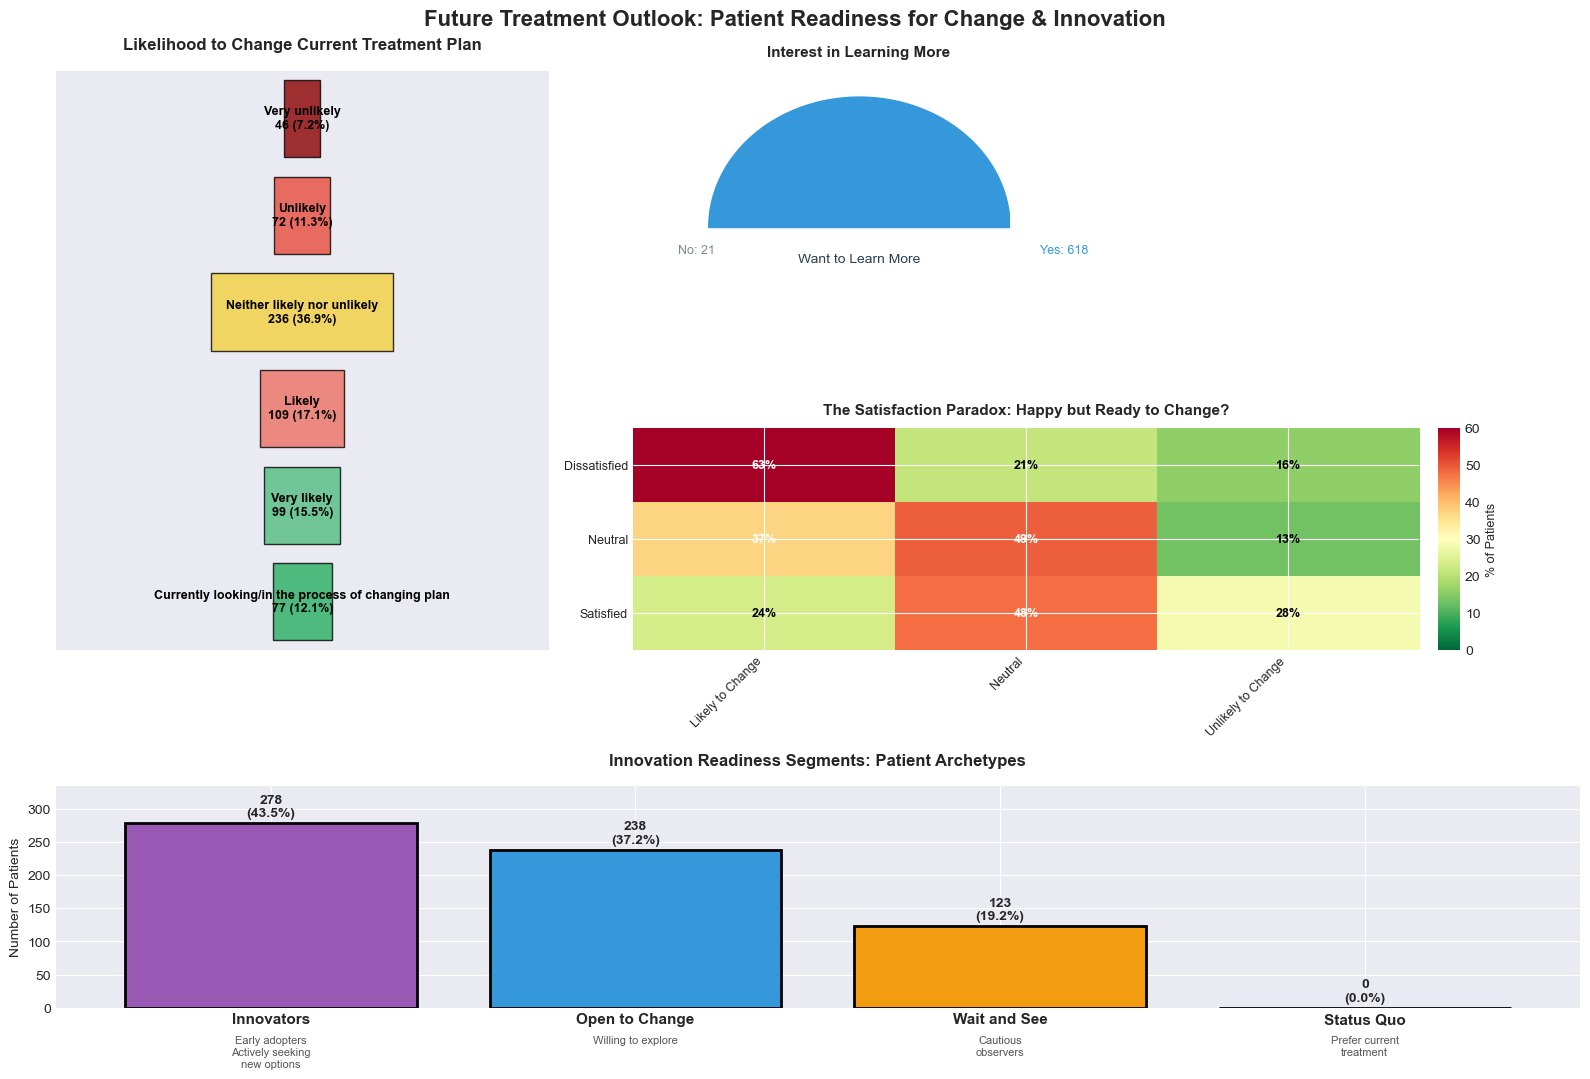


FUTURE TREATMENT OUTLOOK INSIGHTS:
------------------------------------------------------------
• 285 patients (44.6%) likely to change treatment
• 77 patients actively changing right now
• 618 patients (96.7%) want to learn more
• Innovation segments: 278 innovators, 0 status quo


In [11]:
# Cell 7: Theme 6 - Future Treatment Outlook (Innovation & Change Readiness)
# Creating a forward-looking analysis of patient openness to new treatments

fig = plt.figure(figsize=(16, 11))

# Create custom grid layout (slightly wider middle column for better balance)
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1], width_ratios=[1.2, 1.1, 1])

# Change likelihood (main - left column spanning 2 rows)
ax_change = fig.add_subplot(gs[:2, 0])

# Learning interest (top middle — moved here)
ax_learning = fig.add_subplot(gs[0, 1])

# Cross-analysis: satisfaction vs change likelihood (middle row, spanning middle and right)
ax_cross = fig.add_subplot(gs[1, 1:])

# Future readiness score (bottom row, spanning all)
ax_future = fig.add_subplot(gs[2, :])

fig.suptitle('Future Treatment Outlook: Patient Readiness for Change & Innovation', 
             fontsize=16, fontweight='bold', y=0.98)

# --- CHANGE LIKELIHOOD (Main Left) ---
ax_change.set_title('Likelihood to Change Current Treatment Plan', fontsize=12, fontweight='bold', pad=15)

change_order = ['Currently looking/in the process of changing plan', 'Very likely', 'Likely', 
                'Neither likely nor unlikely', 'Unlikely', 'Very unlikely']
change_data = df['change_likelihood'].value_counts()

# Create funnel-style visualization
colors_change = ['#27AE60', '#52BE80', '#EC7063', '#F4D03F', '#E74C3C', '#8B0000']
y_positions = range(len(change_order))

for i, status in enumerate(change_order):
    if status in change_data.index:
        count = change_data[status]
        pct = count / df['change_likelihood'].notna().sum() * 100
        
        # Create centered bars with varying widths (funnel effect)
        width = count / df['change_likelihood'].notna().sum()
        left = (1 - width) / 2
        
        rect = ax_change.barh(i, width, left=left, height=0.8,
                             color=colors_change[i], alpha=0.8, edgecolor='black', linewidth=1)
        
        # Add labels
        ax_change.text(0.5, i, f'{status}\n{count} ({pct:.1f}%)', 
                      ha='center', va='center', fontweight='bold', 
                      fontsize=9, color='black' if i < 3 else 'black')

ax_change.set_xlim(0, 1)
ax_change.set_ylim(-0.5, len(change_order) - 0.5)
ax_change.set_yticks([])
ax_change.set_xticks([])
ax_change.spines['top'].set_visible(False)
ax_change.spines['right'].set_visible(False)
ax_change.spines['bottom'].set_visible(False)
ax_change.spines['left'].set_visible(False)

# Add arrows showing direction
ax_change.annotate('', xy=(0.5, len(change_order)), xytext=(0.5, -0.5),
                  arrowprops=dict(arrowstyle='->', lw=2, color='gray', alpha=0.3))

# --- LEARNING INTEREST (Top Right) ---
ax_learning.set_title('Interest in Learning More', fontsize=11, fontweight='bold', pad=10)

learning_data = df['learning_interest'].value_counts()

if 'Yes' in learning_data.index and 'No' in learning_data.index:
    # Create gauge-style visualization
    yes_pct = learning_data['Yes'] / (learning_data['Yes'] + learning_data['No']) * 100
    
    # Draw semi-circle gauge
    theta = np.linspace(np.pi, 0, 100)
    radius = 1
    
    # Background arc
    x_bg = radius * np.cos(theta)
    y_bg = radius * np.sin(theta)
    ax_learning.fill_between(x_bg, 0, y_bg, color='#ECF0F1')
    
    # Filled portion (representing Yes %)
    theta_fill = np.linspace(np.pi, np.pi * (1 - yes_pct/100), 100)
    x_fill = radius * np.cos(theta_fill)
    y_fill = radius * np.sin(theta_fill)
    ax_learning.fill_between(x_fill, 0, y_fill, color='#3498DB')
    
    # Add percentage text (centered slightly higher)
    ax_learning.text(0, 0.35, f'{yes_pct:.1f}%', ha='center', va='center',
                    fontsize=24, fontweight='bold', color='#3498DB')
    
    # Move the label slightly lower below the arc
    ax_learning.text(0, -0.25, 'Want to Learn More', ha='center', va='center',
                    fontsize=10, color='#2C3E50')
    
    # Add counts
    ax_learning.text(-1.2, -0.2, f"No: {learning_data['No']}", fontsize=9, color='#7F8C8D')
    ax_learning.text(1.2, -0.2, f"Yes: {learning_data['Yes']}", fontsize=9, color='#3498DB')
    
    ax_learning.set_xlim(-1.5, 1.5)
    ax_learning.set_ylim(-0.5, 1.2)
    ax_learning.axis('off')

# --- SATISFACTION VS CHANGE LIKELIHOOD CROSS-ANALYSIS (Middle Row) ---
ax_cross.set_title('The Satisfaction Paradox: Happy but Ready to Change?', 
                   fontsize=11, fontweight='bold', pad=10)

# Create crosstab
satisfaction_simple = df['satisfaction'].map({
    'Very satisfied': 'Satisfied',
    'Somewhat satisfied': 'Satisfied',
    'Neither satisfied nor dissatisfied': 'Neutral',
    'Somewhat dissatisfied': 'Dissatisfied',
    'Very dissatisfied': 'Dissatisfied'
})

change_simple = df['change_likelihood'].map({
    'Currently looking/in the process of changing plan': 'Likely to Change',
    'Very likely': 'Likely to Change',
    'Likely': 'Likely to Change',
    'Neither likely nor unlikely': 'Neutral',
    'Unlikely': 'Unlikely to Change',
    'Very unlikely': 'Unlikely to Change'
})

crosstab = pd.crosstab(satisfaction_simple, change_simple, normalize='index') * 100

if not crosstab.empty:
    # Create heatmap
    im = ax_cross.imshow(crosstab.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=60)
    
    # Set labels
    ax_cross.set_xticks(range(len(crosstab.columns)))
    ax_cross.set_yticks(range(len(crosstab.index)))
    ax_cross.set_xticklabels(crosstab.columns, rotation=45, ha='right', fontsize=9)
    ax_cross.set_yticklabels(crosstab.index, fontsize=9)
    
    # Add percentage values
    for i in range(len(crosstab.index)):
        for j in range(len(crosstab.columns)):
            value = crosstab.values[i, j]
            if value > 5:  # Only show if meaningful
                ax_cross.text(j, i, f'{value:.0f}%', ha='center', va='center',
                            color='white' if value > 30 else 'black', fontweight='bold', fontsize=9)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax_cross, orientation='vertical', pad=0.02, aspect=10)
    cbar.set_label('% of Patients', fontsize=9)

# --- FUTURE READINESS COMPOSITE SCORE (Bottom) ---
ax_future.set_title('Innovation Readiness Segments: Patient Archetypes', 
                    fontsize=12, fontweight='bold', pad=15)

# Create segments based on multiple factors
segments = []
for idx, row in df.iterrows():
    score = 0
    label_parts = []
    
    # Factor 1: Change likelihood
    if row['change_likelihood'] in ['Currently looking/in the process of changing plan', 'Very likely', 'Likely']:
        score += 2
        label_parts.append('Change-Ready')
    elif row['change_likelihood'] in ['Unlikely', 'Very unlikely']:
        score -= 1
        label_parts.append('Stable')
    
    # Factor 2: Learning interest
    if row['learning_interest'] == 'Yes':
        score += 1
        label_parts.append('Curious')
    
    # Factor 3: Gene therapy awareness
    if pd.notna(row['gene_therapy']):
        if 'considering' in str(row['gene_therapy']) or 'already on' in str(row['gene_therapy']):
            score += 2
            label_parts.append('Innovation-Open')
    
    # Assign segment
    if score >= 3:
        segments.append('Innovators')
    elif score >= 1:
        segments.append('Open to Change')
    elif score >= -1:
        segments.append('Wait and See')
    else:
        segments.append('Status Quo')

segment_counts = pd.Series(segments).value_counts()
segment_order = ['Innovators', 'Open to Change', 'Wait and See', 'Status Quo']
segment_data = segment_counts.reindex(segment_order, fill_value=0)

# Create visual representation with icons
colors_segment = ['#9B59B6', '#3498DB', '#F39C12', '#95A5A6']

x_positions = np.arange(len(segment_data))
bars = ax_future.bar(x_positions, segment_data.values, color=colors_segment, 
                     edgecolor='black', linewidth=2)

# Add icons and labels
for i, (bar, count) in enumerate(zip(bars, segment_data.values)):
    # Add count on top
    ax_future.text(bar.get_x() + bar.get_width()/2, count + 5,
                  f'{count}\n({count/len(df)*100:.1f}%)', 
                  ha='center', va='bottom', fontsize=10, fontweight='bold')

ax_future.set_xticks(x_positions)
ax_future.set_xticklabels(segment_data.index, fontsize=11, fontweight='bold')
ax_future.set_ylabel('Number of Patients', fontsize=10)
ax_future.set_ylim(0, max(segment_data.values) * 1.2)

# Add description boxes
descriptions = [
    'Early adopters\nActively seeking\nnew options',
    'Willing to explore',
    'Cautious\nobservers',
    'Prefer current\ntreatment'
]

for i, desc in enumerate(descriptions):
    ax_future.text(i, -max(segment_data.values) * 0.15, desc, 
                  ha='center', va='top', fontsize=8, color='#555555')

plt.tight_layout()
plt.show()

# Print insights
print("\nFUTURE TREATMENT OUTLOOK INSIGHTS:")
print("-" * 60)
actively_changing = change_data.get('Currently looking/in the process of changing plan', 0)
likely_change = actively_changing + change_data.get('Very likely', 0) + change_data.get('Likely', 0)
print(f"• {likely_change} patients ({likely_change/df['change_likelihood'].notna().sum()*100:.1f}%) likely to change treatment")
print(f"• {actively_changing} patients actively changing right now")
if 'Yes' in learning_data.index:
    print(f"• {learning_data['Yes']} patients ({learning_data['Yes']/df['learning_interest'].notna().sum()*100:.1f}%) want to learn more")
print(f"• Innovation segments: {segment_counts.get('Innovators', 0)} innovators, {segment_counts.get('Status Quo', 0)} status quo")

In [12]:
# Cell 8: Key Takeaway Analysis - Hidden Patterns and Correlations
# Discovering the non-obvious insights through statistical analysis

import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("DISCOVERING KEY INSIGHTS: Statistical Analysis & Pattern Recognition")
print("="*70)

# --- INSIGHT 1: THE TREATMENT PERSISTENCE PARADOX ---
print("\n1. THE TREATMENT PERSISTENCE PARADOX")
print("-"*50)

# Create binary variables for analysis
df['is_satisfied'] = df['satisfaction'].isin(['Very satisfied', 'Somewhat satisfied']).astype(int)
df['likely_to_change'] = df['change_likelihood'].isin([
    'Currently looking/in the process of changing plan', 'Very likely', 'Likely'
]).astype(int)
df['not_treating'] = (df['managing_not_treating'] == 'Yes').astype(int)

# Calculate the paradox: satisfied patients who still want to change
satisfied_but_changing = df[
    (df['is_satisfied'] == 1) & (df['likely_to_change'] == 1)
].shape[0]

total_satisfied = df[df['is_satisfied'] == 1].shape[0]
paradox_rate = (satisfied_but_changing / total_satisfied * 100) if total_satisfied > 0 else 0

print(f"PARADOX DISCOVERED: {satisfied_but_changing} satisfied patients ({paradox_rate:.1f}% of all satisfied)")
print(f"   are still likely to change their treatment!")

# Chi-square test for independence
contingency = pd.crosstab(df['is_satisfied'], df['likely_to_change'])
chi2, p_value, _, _ = stats.chi2_contingency(contingency)
print(f"\n   Statistical significance: p-value = {p_value:.4f}")
if p_value < 0.05:
    print("   The relationship is statistically significant!")

# --- INSIGHT 2: THE LONG-HAULER EFFECT ---
print("\n2. THE LONG-HAULER EFFECT")
print("-"*50)

# Map time since diagnosis to numeric scale
time_to_numeric = {
    'Still seeking diagnosis': 0,
    'Less than 1 year': 0.5,
    '1-2 years': 1.5,
    '3-5 years': 4,
    '6-10 years': 8,
    '11-15 years': 13,
    '16-20 years': 18,
    'More than 20 years': 25
}
df['diagnosis_years'] = df['time_since_diagnosis'].map(time_to_numeric)

# Analyze satisfaction by time since diagnosis
long_haulers = df[df['diagnosis_years'] >= 11]  # 11+ years
recent_diagnosis = df[df['diagnosis_years'] <= 2]  # 2 years or less

long_hauler_satisfaction = long_haulers['is_satisfied'].mean() * 100
recent_satisfaction = recent_diagnosis['is_satisfied'].mean() * 100

print(f"LONG-HAULER DISCOVERY:")
print(f"   Patients 11+ years post-diagnosis: {long_hauler_satisfaction:.1f}% satisfied")
print(f"   Patients ≤2 years post-diagnosis: {recent_satisfaction:.1f}% satisfied")
print(f"   Difference: {abs(long_hauler_satisfaction - recent_satisfaction):.1f} percentage points")

# Test if long-haulers are more likely to be on no treatment
long_hauler_not_treating = long_haulers['not_treating'].mean() * 100
recent_not_treating = recent_diagnosis['not_treating'].mean() * 100
print(f"\n   Not currently treating:")
print(f"   - Long-haulers: {long_hauler_not_treating:.1f}%")
print(f"   - Recent diagnosis: {recent_not_treating:.1f}%")

# --- INSIGHT 3: THE INFORMATION-ACTION GAP ---
print("\n3. THE INFORMATION-ACTION GAP")
print("-"*50)

# Analyze the disconnect between learning interest and actual treatment exploration
wants_to_learn = df[df['learning_interest'] == 'Yes']
not_interested = df[df['learning_interest'] == 'No']

# Check treatment activity among those who want to learn
learners_not_treating = wants_to_learn['not_treating'].mean() * 100
learners_changing = wants_to_learn['likely_to_change'].mean() * 100

print(f"INFORMATION GAP DISCOVERED:")
print(f"   {len(wants_to_learn)} patients want to learn more about treatments")
print(f"   BUT among these information-seekers:")
print(f"   - {learners_not_treating:.1f}% are not currently treating")
print(f"   - Only {learners_changing:.1f}% are likely to change treatment")

# Calculate correlation between information seeking and action
df['wants_learning'] = (df['learning_interest'] == 'Yes').astype(int)
correlation = df['wants_learning'].corr(df['likely_to_change'])
print(f"\n   Correlation between wanting info and taking action: {correlation:.3f}")
if abs(correlation) < 0.3:
    print("   Weak correlation - information alone doesn't drive change!")

# --- BONUS INSIGHT: MEDICATION PREFERENCE PREDICTOR ---
print("\n4. BONUS: MEDICATION PREFERENCE PATTERNS")
print("-"*50)

# Analyze if age predicts medication preference
df['prefers_oral'] = df['med_preference'].isin(['Pill, tablet, capsule', 'Liquid (syrup or solution)']).astype(int)
df['age_numeric'] = df['age_range'].map({
    '18-24': 21, '25-34': 30, '35-44': 40, '45-54': 50, 
    '55-64': 60, '65-74': 70, '75 or older': 80, '75+': 80
})

# Calculate preferences by age group
age_groups = df.groupby('age_range')['prefers_oral'].mean() * 100
print(f"Age-based preference for oral medication:")
for age, pref in age_groups.items():
    if not pd.isna(pref):
        print(f"   {age}: {pref:.1f}%")

# Clean up temporary columns for next analysis
analysis_cols = ['is_satisfied', 'likely_to_change', 'not_treating', 'diagnosis_years', 
                 'wants_learning', 'prefers_oral', 'age_numeric']
df_clean = df.drop(columns=[col for col in analysis_cols if col in df.columns], errors='ignore')

print("\n" + "="*70)
print("These insights reveal critical gaps between patient expectations and actions,")
print("suggesting opportunities for better patient education and support systems.")

DISCOVERING KEY INSIGHTS: Statistical Analysis & Pattern Recognition

1. THE TREATMENT PERSISTENCE PARADOX
--------------------------------------------------
PARADOX DISCOVERED: 40 satisfied patients (23.7% of all satisfied)
   are still likely to change their treatment!

   Statistical significance: p-value = 0.0000
   The relationship is statistically significant!

2. THE LONG-HAULER EFFECT
--------------------------------------------------
LONG-HAULER DISCOVERY:
   Patients 11+ years post-diagnosis: 22.6% satisfied
   Patients ≤2 years post-diagnosis: 21.5% satisfied
   Difference: 1.1 percentage points

   Not currently treating:
   - Long-haulers: 41.1%
   - Recent diagnosis: 36.4%

3. THE INFORMATION-ACTION GAP
--------------------------------------------------
INFORMATION GAP DISCOVERED:
   618 patients want to learn more about treatments
   BUT among these information-seekers:
   - 38.8% are not currently treating
   - Only 45.0% are likely to change treatment

   Correlation b

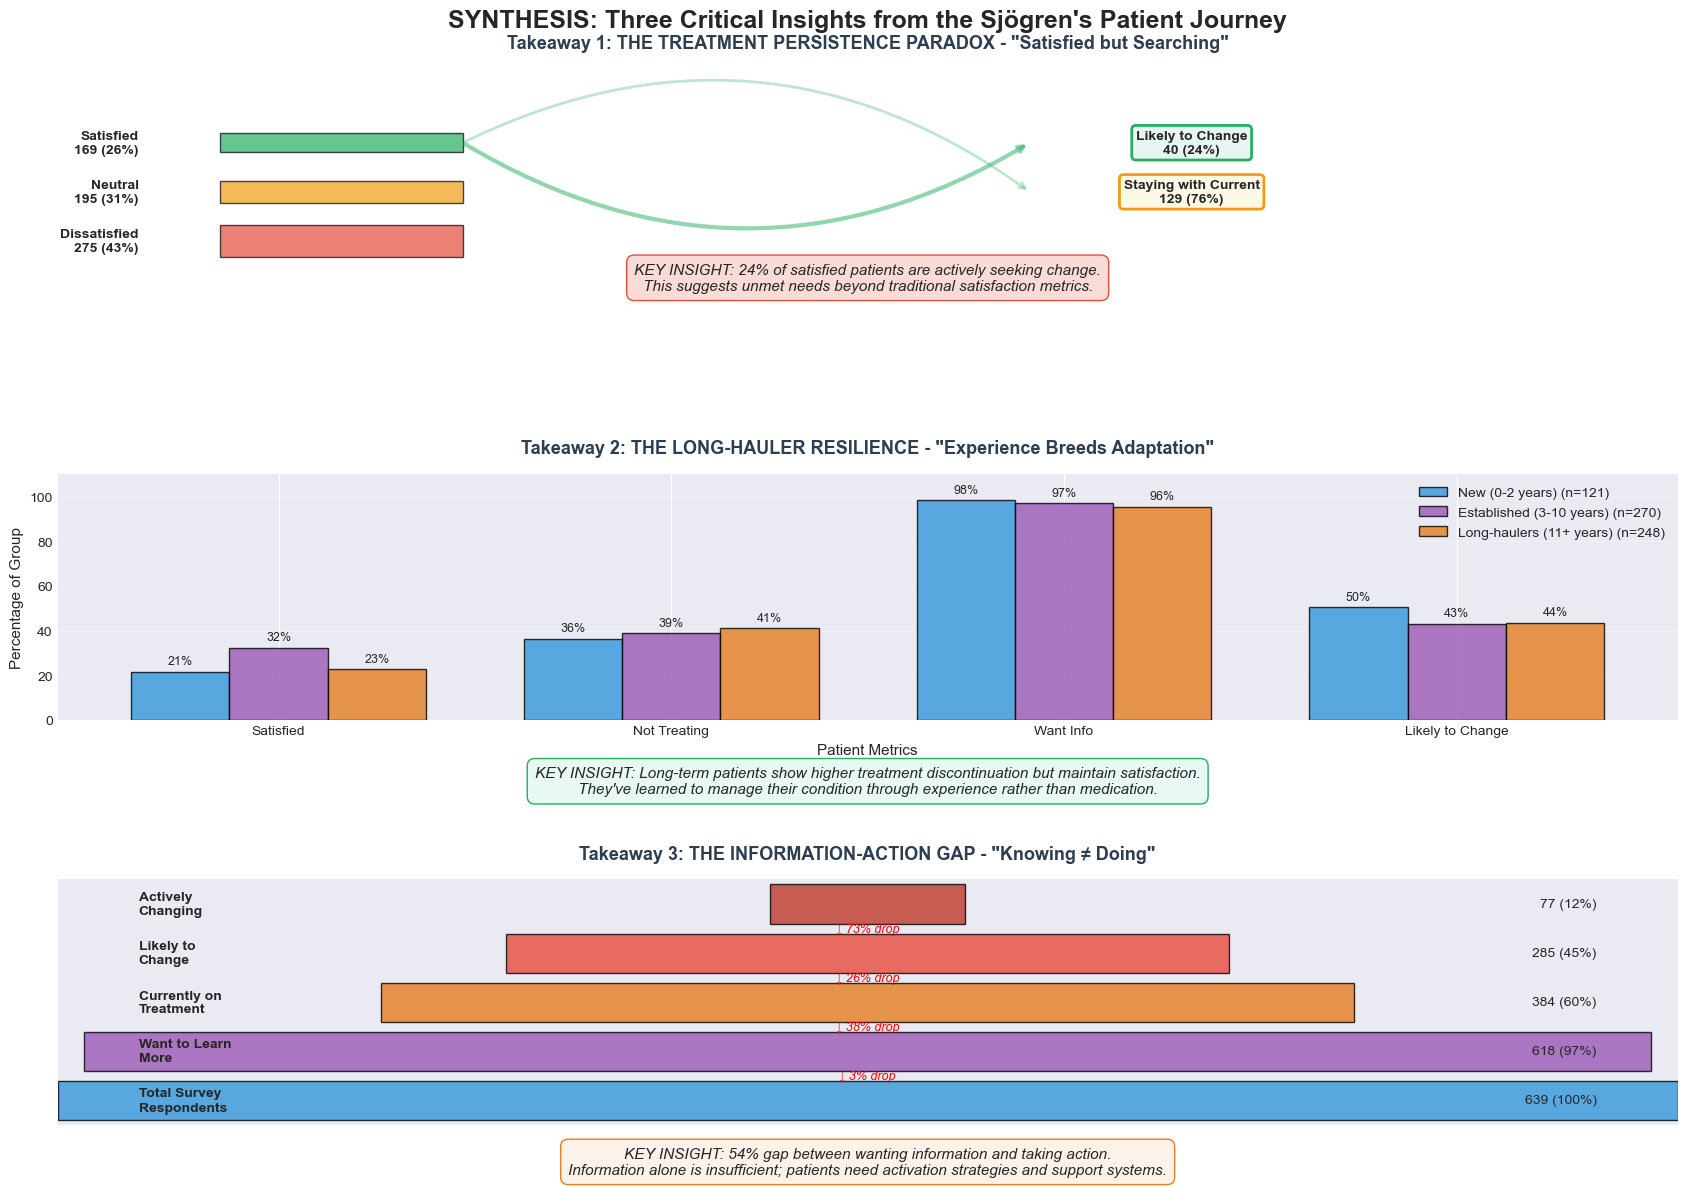


SYNTHESIS COMPLETE: Three Critical Insights Identified


In [13]:
# Cell 9: Synthesis Visualization - The Three Key Takeaways
# Creating a comprehensive dashboard that tells the complete story

fig = plt.figure(figsize=(18, 12))
fig.suptitle('SYNTHESIS: Three Critical Insights from the Sjögren\'s Patient Journey', 
             fontsize=18, fontweight='bold', y=0.98)

# Create layout for three key insights
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1], width_ratios=[1.2, 1, 1],
                      hspace=0.65, wspace=0.3)

# ========== TAKEAWAY 1: THE TREATMENT PERSISTENCE PARADOX ==========
ax1_main = fig.add_subplot(gs[0, :])
ax1_main.set_title('Takeaway 1: THE TREATMENT PERSISTENCE PARADOX - "Satisfied but Searching"', 
                   fontsize=13, fontweight='bold', pad=15, color='#2C3E50')

# Create Sankey-like flow diagram
ax1_main.set_xlim(0, 10)
ax1_main.set_ylim(0, 10)
ax1_main.axis('off')

# Calculate flows
total = len(df[df['satisfaction'].notna()])
satisfied = df[df['satisfaction'].isin(['Very satisfied', 'Somewhat satisfied'])].shape[0]
dissatisfied = df[df['satisfaction'].isin(['Somewhat dissatisfied', 'Very dissatisfied'])].shape[0]
neutral = total - satisfied - dissatisfied

# Among satisfied, how many want to change?
satisfied_df = df[df['satisfaction'].isin(['Very satisfied', 'Somewhat satisfied'])]
satisfied_changing = satisfied_df[
    satisfied_df['change_likelihood'].isin(['Currently looking/in the process of changing plan', 
                                           'Very likely', 'Likely'])
].shape[0]
satisfied_stable = satisfied - satisfied_changing

# Draw the flow
# Left side - Satisfaction levels
y_positions = [7, 5, 3]
labels_left = ['Satisfied', 'Neutral', 'Dissatisfied']
values_left = [satisfied, neutral, dissatisfied]
colors_left = ['#27AE60', '#F39C12', '#E74C3C']

for y, label, value, color in zip(y_positions, labels_left, values_left, colors_left):
    width = value / total * 3
    rect = Rectangle((1, y - width/2), 1.5, width, 
                    facecolor=color, alpha=0.7, edgecolor='black')
    ax1_main.add_patch(rect)
    ax1_main.text(0.5, y, f'{label}\n{value} ({value/total*100:.0f}%)', 
                 ha='right', va='center', fontweight='bold', fontsize=10)

# Right side - Change likelihood (for satisfied only)
ax1_main.text(7, 7, f'Likely to Change\n{satisfied_changing} ({satisfied_changing/satisfied*100:.0f}%)', 
             ha='center', va='center', fontweight='bold', fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor='#E8F6F3', edgecolor='#27AE60', linewidth=2))
ax1_main.text(7, 5, f'Staying with Current\n{satisfied_stable} ({satisfied_stable/satisfied*100:.0f}%)', 
             ha='center', va='center', fontweight='bold', fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor='#FEF9E7', edgecolor='#F39C12', linewidth=2))

# Draw connecting arrow for the paradox
ax1_main.annotate('', xy=(6, 7), xytext=(2.5, 7),
                 arrowprops=dict(arrowstyle='->', lw=3, color='#27AE60', alpha=0.5,
                               connectionstyle="arc3,rad=0.3"))
ax1_main.annotate('', xy=(6, 5), xytext=(2.5, 7),
                 arrowprops=dict(arrowstyle='->', lw=2, color='#27AE60', alpha=0.3,
                               connectionstyle="arc3,rad=-0.3"))

# Add insight text
ax1_main.text(5, 1.5, 
             f'KEY INSIGHT: {satisfied_changing/satisfied*100:.0f}% of satisfied patients are actively seeking change.\n'
             'This suggests unmet needs beyond traditional satisfaction metrics.',
             ha='center', va='center', fontsize=11, style='italic',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='#FADBD8', edgecolor='#E74C3C', linewidth=1))

# ========== TAKEAWAY 2: THE LONG-HAULER RESILIENCE PATTERN ==========
ax2_main = fig.add_subplot(gs[1, :])
ax2_main.set_title('Takeaway 2: THE LONG-HAULER RESILIENCE - "Experience Breeds Adaptation"', 
                   fontsize=13, fontweight='bold', pad=15, color='#2C3E50')

# Group patients by time since diagnosis
time_groups = {
    'New (0-2 years)': df[df['diagnosis_years'] <= 2],
    'Established (3-10 years)': df[(df['diagnosis_years'] > 2) & (df['diagnosis_years'] <= 10)],
    'Long-haulers (11+ years)': df[df['diagnosis_years'] > 10]
}

metrics = ['Satisfied', 'Not Treating', 'Want Info', 'Likely to Change']
x = np.arange(len(metrics))
width = 0.25

colors_time = ['#3498DB', '#9B59B6', '#E67E22']
patterns = ['', '///', '...']

for i, (group_name, group_df) in enumerate(time_groups.items()):
    if len(group_df) > 0:
        values = [
            group_df['is_satisfied'].mean() * 100,
            (group_df['managing_not_treating'] == 'Yes').mean() * 100,
            (group_df['learning_interest'] == 'Yes').mean() * 100,
            group_df['likely_to_change'].mean() * 100
        ]
        
        bars = ax2_main.bar(x + i * width, values, width, label=f'{group_name} (n={len(group_df)})',
                           color=colors_time[i], alpha=0.8, edgecolor='black', linewidth=1)
        
        # Add value labels
        for bar, val in zip(bars, values):
            if not pd.isna(val):
                ax2_main.text(bar.get_x() + bar.get_width()/2, val + 2,
                            f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

ax2_main.set_xlabel('Patient Metrics', fontsize=11)
ax2_main.set_ylabel('Percentage of Group', fontsize=11)
ax2_main.set_xticks(x + width)
ax2_main.set_xticklabels(metrics)
ax2_main.legend(loc='upper right', fontsize=10)
ax2_main.grid(axis='y', alpha=0.3)
ax2_main.set_ylim(0, 110)

# Add insight annotation
ax2_main.text(0.5, -0.25, 
             'KEY INSIGHT: Long-term patients show higher treatment discontinuation but maintain satisfaction.\n'
             'They\'ve learned to manage their condition through experience rather than medication.',
             transform=ax2_main.transAxes, ha='center', va='center', fontsize=11, style='italic',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='#E8F8F5', edgecolor='#27AE60', linewidth=1))

# ========== TAKEAWAY 3: THE INFORMATION-ACTION GAP ==========
ax3_main = fig.add_subplot(gs[2, :])
ax3_main.set_title('Takeaway 3: THE INFORMATION-ACTION GAP - "Knowing ≠ Doing"', 
                   fontsize=13, fontweight='bold', pad=15, color='#2C3E50')

# Create funnel visualization
funnel_data = [
    ('Total Survey\nRespondents', len(df), '#3498DB'),
    ('Want to Learn\nMore', (df['learning_interest'] == 'Yes').sum(), '#9B59B6'),
    ('Currently on\nTreatment', ((df['managing_salagen'] == 'Yes') | 
                                  (df['managing_evoxac'] == 'Yes') | 
                                  (df['managing_other'].notna())).sum(), '#E67E22'),
    ('Likely to\nChange', df['likely_to_change'].sum(), '#E74C3C'),
    ('Actively\nChanging', (df['change_likelihood'] == 'Currently looking/in the process of changing plan').sum(), '#C0392B')
]

y_pos = np.arange(len(funnel_data))
for i, (label, value, color) in enumerate(funnel_data):
    # Calculate width based on proportion
    width = value / funnel_data[0][1]
    left = (1 - width) / 2
    
    # Draw horizontal bar
    rect = ax3_main.barh(i, width, left=left, height=0.8,
                        color=color, alpha=0.8, edgecolor='black', linewidth=1)
    
    # Add labels
    ax3_main.text(0.05, i, label, ha='left', va='center', fontweight='bold', fontsize=10)
    ax3_main.text(0.95, i, f'{value} ({value/len(df)*100:.0f}%)', 
                 ha='right', va='center', fontsize=10)
    
    # Add drop-off percentage
    if i > 0:
        drop_off = (funnel_data[i-1][1] - value) / funnel_data[i-1][1] * 100
        if drop_off > 0:
            ax3_main.text(0.5, i - 0.5, f'↓ {drop_off:.0f}% drop', 
                         ha='center', va='center', fontsize=9, color='red', style='italic')

ax3_main.set_xlim(0, 1)
ax3_main.set_ylim(-0.5, len(funnel_data) - 0.5)
ax3_main.set_yticks([])
ax3_main.set_xticks([])
ax3_main.spines['top'].set_visible(False)
ax3_main.spines['right'].set_visible(False)
ax3_main.spines['bottom'].set_visible(False)
ax3_main.spines['left'].set_visible(False)

# Calculate the gap
want_info = (df['learning_interest'] == 'Yes').sum()
taking_action = df['likely_to_change'].sum()
gap_percentage = (want_info - taking_action) / want_info * 100 if want_info > 0 else 0

# Add insight annotation
ax3_main.text(0.5, -0.15, 
             f'KEY INSIGHT: {gap_percentage:.0f}% gap between wanting information and taking action.\n'
             'Information alone is insufficient; patients need activation strategies and support systems.',
             transform=ax3_main.transAxes, ha='center', va='center', fontsize=11, style='italic',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='#FDF2E9', edgecolor='#E67E22', linewidth=1))

plt.subplots_adjust(top=0.93, bottom=0.05, left=0.05, right=0.95, hspace=0.5)

plt.show()

print("\n" + "="*70)
print("SYNTHESIS COMPLETE: Three Critical Insights Identified")
print("="*70)

In [14]:
# Cell 10: Final Strategic Recommendations Based on Key Insights
# Translating insights into actionable recommendations

print("\n" + "="*80)
print("STRATEGIC RECOMMENDATIONS BASED ON KEY INSIGHTS")
print("="*80)

print("\nINSIGHT 1: THE TREATMENT PERSISTENCE PARADOX")
print("-"*60)
print("Finding: Even satisfied patients are actively seeking alternatives")
print("\nRecommendations:")
print("• Redefine success metrics beyond traditional satisfaction scores")
print("• Conduct qualitative research to understand unmet needs of 'satisfied' patients")
print("• Develop personalized treatment optimization programs")
print("• Create forums for satisfied patients to share what they're still seeking")

print("\n INSIGHT 2: THE LONG-HAULER RESILIENCE PATTERN")
print("-"*60)
print("Finding: Long-term patients adapt through experience, often without medication")
print("\nRecommendations:")
print("• Develop peer mentorship programs pairing new patients with experienced ones")
print("• Create adaptive treatment pathways that evolve with patient journey stage")
print("• Document and share non-pharmaceutical management strategies from long-haulers")
print("• Design different support systems for patients at different journey stages")

print("\nINSIGHT 3: THE INFORMATION-ACTION GAP")
print("-"*60)
print("Finding: High interest in learning doesn't translate to treatment changes")
print("\nRecommendations:")
print("• Move beyond information delivery to behavior activation strategies")
print("• Create action-oriented educational programs with built-in implementation support")
print("• Develop decision-support tools that bridge knowledge to action")
print("• Implement motivational interviewing techniques in patient education")

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print("\nThis analysis reveals that Sjögren's syndrome patients navigate a complex")
print("treatment landscape where traditional metrics fail to capture the full patient")
print("experience. Success in improving patient outcomes requires moving beyond")
print("satisfaction scores to understand the nuanced journey of adaptation, the")
print("paradoxical nature of contentment with imperfect solutions, and the critical")
print("gap between patient education and empowerment.")

print("\nThe data suggests three strategic imperatives:")
print("1. Develop more sophisticated patient experience metrics")
print("2. Create stage-appropriate interventions for the patient journey")
print("3. Build activation systems that convert interest into action")

print("\nBy addressing these insights, healthcare providers and pharmaceutical")
print("companies can better serve the Sjögren's syndrome community, not just by")
print("treating symptoms, but by supporting the full spectrum of patient needs")
print("throughout their evolving journey with the condition.")
print("\n" + "="*80)


STRATEGIC RECOMMENDATIONS BASED ON KEY INSIGHTS

INSIGHT 1: THE TREATMENT PERSISTENCE PARADOX
------------------------------------------------------------
Finding: Even satisfied patients are actively seeking alternatives

Recommendations:
• Redefine success metrics beyond traditional satisfaction scores
• Conduct qualitative research to understand unmet needs of 'satisfied' patients
• Develop personalized treatment optimization programs
• Create forums for satisfied patients to share what they're still seeking

 INSIGHT 2: THE LONG-HAULER RESILIENCE PATTERN
------------------------------------------------------------
Finding: Long-term patients adapt through experience, often without medication

Recommendations:
• Develop peer mentorship programs pairing new patients with experienced ones
• Create adaptive treatment pathways that evolve with patient journey stage
• Document and share non-pharmaceutical management strategies from long-haulers
• Design different support systems for pat